In [1]:
%cd ../.
import os, sys
sys.path.insert(0, os.path.abspath('../Scripts'))
sys.path.insert(0, os.path.expanduser('~/CDD_Vault_API/python'))  # CDD Vault API (get_df)

/home/gtamo/ADME_ML


In [2]:
%load_ext autoreload
%autoreload 2

import re
import os
import pandas as pd
import numpy as np
import py3Dmol
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import csv
import pickle

from pathlib import Path
from rdkit import Chem
from rdkit.Chem import AllChem,rdFMCS
# import prolif as plf
from glob import glob
import meeko
import subprocess as sub
# from vina import Vina
import time
from tqdm import tqdm
tqdm.pandas()
import importlib
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, HistGradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold, cross_val_predict, KFold
from sklearn.metrics import f1_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import roc_auc_score, average_precision_score, matthews_corrcoef
from xgboost import XGBClassifier,XGBRegressor
from openTSNE import TSNE as oTSNE        # pip install openTSNE
import seaborn as sns
from scipy import stats
import csv, contextlib, threading, joblib
import joblib
from joblib import Parallel, delayed
from datetime import date
## load internal (in-house) + public-augmented data, champion model, eval helpers
from copy import deepcopy

# user defined modules
import Rdkit_tools as rdkit_tools
importlib.reload(rdkit_tools)
import Molecule as M
import ML_Reg as ML_Reg
import ML_Class as ML_Class
from MolViz3D import MolViz3D
import Statistics_tools as stats_tools
import python.functions as fn
from python.harmonize_sol import harmonize_solubility

from get_library import get_df   # CDD Vault collection export
from get_protocol_data import get_data, load_config, alias_map
# from tdc.multi_pred import DTI

In [3]:
## params — single source of truth in config/config.yaml.
## Loaded as a `config` namespace AND injected as globals, so both
import yaml
from types import SimpleNamespace
with open('config/config.yaml') as _f:
    _cfg = yaml.safe_load(_f)
config = SimpleNamespace(**_cfg)
globals().update(_cfg)
print(f'> loaded {len(_cfg)} params from config/config.yaml')


## paths are relative to this notebook (vignettes/)
CONFIG = '../CDD_Vault_API/config/config.yaml'
TOKEN_FILE = '../.cdd_token'   # a READ token is enough to extract

alias_map(load_config(CONFIG))

> loaded 29 params from config/config.yaml


{'mdck': (131399, 'MDR1-MDCK II Inhibitor'),
 'logd': (85979, 'LogD'),
 'solubility': (86015, 'Thermodynamic Solubility'),
 'ppb': (125963, 'Plasma protein binding (UC)'),
 'hlm': (88861, 'Microsomal stability species human'),
 'mlm': (88862, 'Microsomal stability species mouse'),
 'caco2': (85977, 'Caco-2 permeability'),
 'rlm': (111161, 'Microsomal stability species rat')}

###  2026-07-20 Data Analysis - raw predicted and experimental data (issues with outliers)

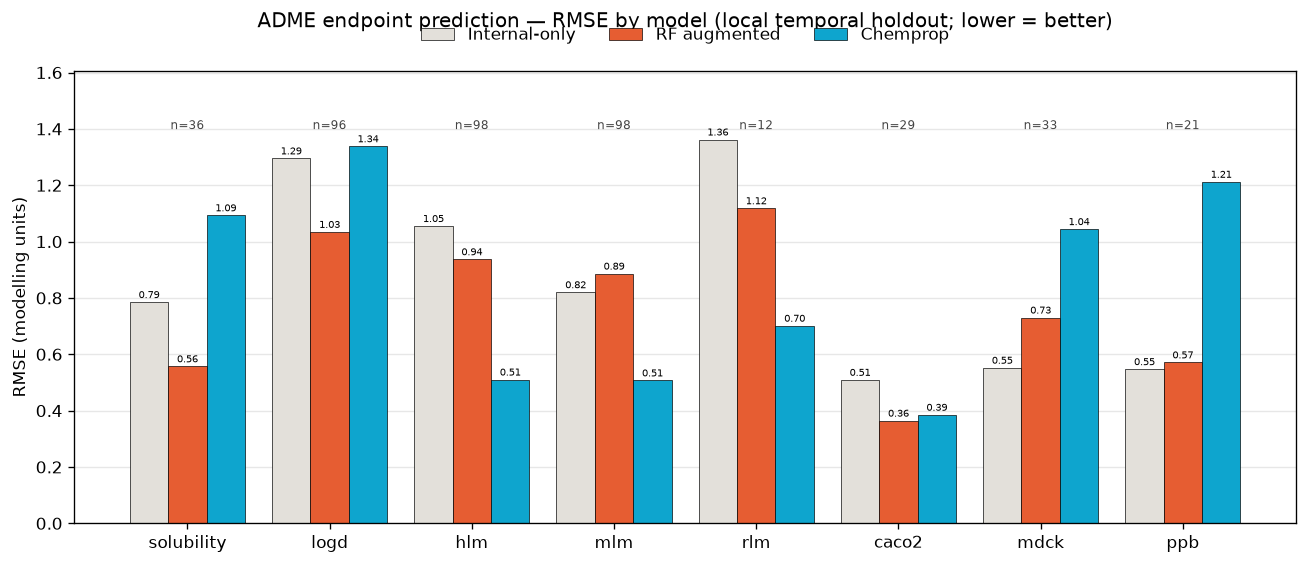

In [5]:
## plot RMSEs:  (RMSE in each endpoint's modelling units — comparable across models within an endpoint, not across endpoints)
import yaml
palette = yaml.safe_load(open('config/config.yaml'))['SERAC_C']
res = pd.read_csv('output/predictions_runs/summary_best_r2_rmse.csv')

groups = [('RFint_rmse', 'Internal-only', palette['paper']),   # RF, internal compounds only
          ('RFaug_rmse', 'RF augmented', palette['ember']),    # RF, internal + public
          ('CP_rmse',    'Chemprop',     palette['azure'])]     # multitask D-MPNN (winning grouping)
x = np.arange(len(res)); w = 0.27
ymax = res[[g[0] for g in groups]].to_numpy().max()

fig, ax = plt.subplots(figsize=(11, 4.8), dpi=120)
for i, (col, label, color) in enumerate(groups):
    bars = ax.bar(x + (i - 1) * w, res[col], w, label=label, color=color, edgecolor='black', linewidth=0.4)
    ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)
for xi, n in zip(x, res['n']):                                # temporal test size (same for all 3 models)
    ax.text(xi, ymax * 1.02, f'n={int(n)}', ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x); ax.set_xticklabels(res['endpoint'])
ax.set_ylabel('RMSE (modelling units)'); ax.set_ylim(0, ymax * 1.18)
ax.set_title('ADME endpoint prediction — RMSE by model (local temporal holdout; lower = better)', pad=26)
ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

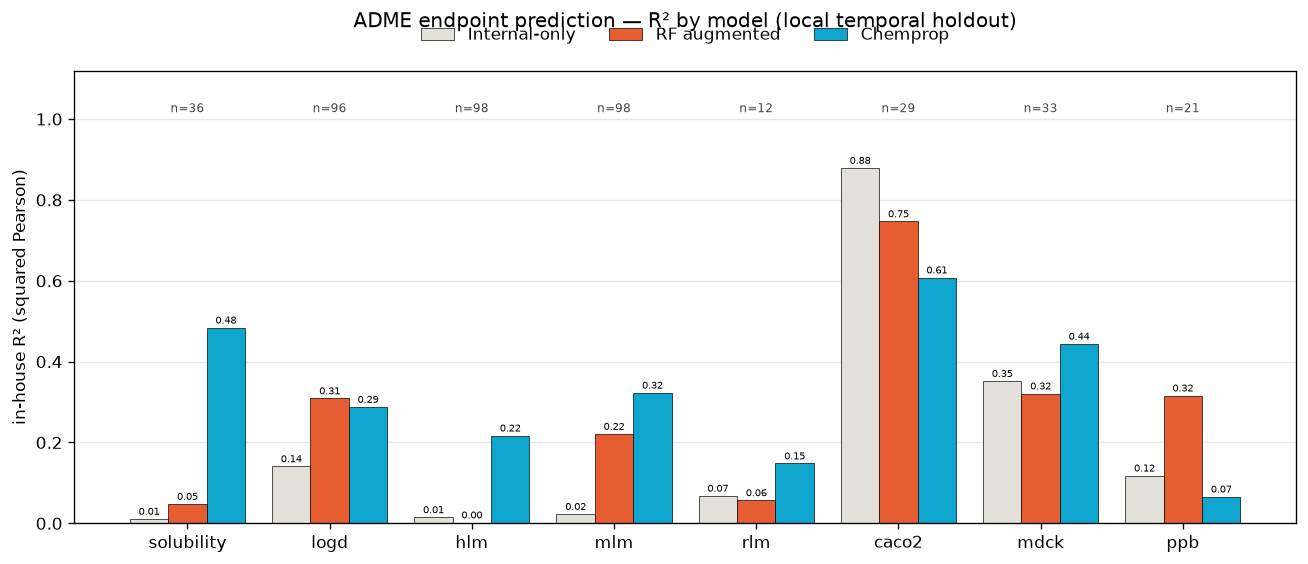

In [6]:
## plot results: grouped bar of in-house R2 per endpoint x model (temporal holdout)
import yaml
palette = yaml.safe_load(open('config/config.yaml'))['SERAC_C']
res = pd.read_csv('output/predictions_runs/summary_best_r2_rmse.csv')

groups = [('RFint_r2', 'Internal-only', palette['paper']),   # RF, internal compounds only
          ('RFaug_r2', 'RF augmented', palette['ember']),    # RF, internal + public
          ('CP_r2',    'Chemprop',     palette['azure'])]     # multitask D-MPNN (winning grouping)
x = np.arange(len(res)); w = 0.27

fig, ax = plt.subplots(figsize=(11, 4.8), dpi=120)
for i, (col, label, color) in enumerate(groups):
    bars = ax.bar(x + (i - 1) * w, res[col], w, label=label, color=color, edgecolor='black', linewidth=0.4)
    ax.bar_label(bars, fmt='%.2f', fontsize=6, padding=1)
for xi, n in zip(x, res['n']):                                # temporal test size (same for all 3 models)
    ax.text(xi, 1.01, f'n={int(n)}', ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x); ax.set_xticklabels(res['endpoint'])
ax.set_ylabel('in-house R² (squared Pearson)'); ax.set_ylim(0, 1.12)
ax.set_title('ADME endpoint prediction — R² by model (local temporal holdout)', pad=26)
ax.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.13))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


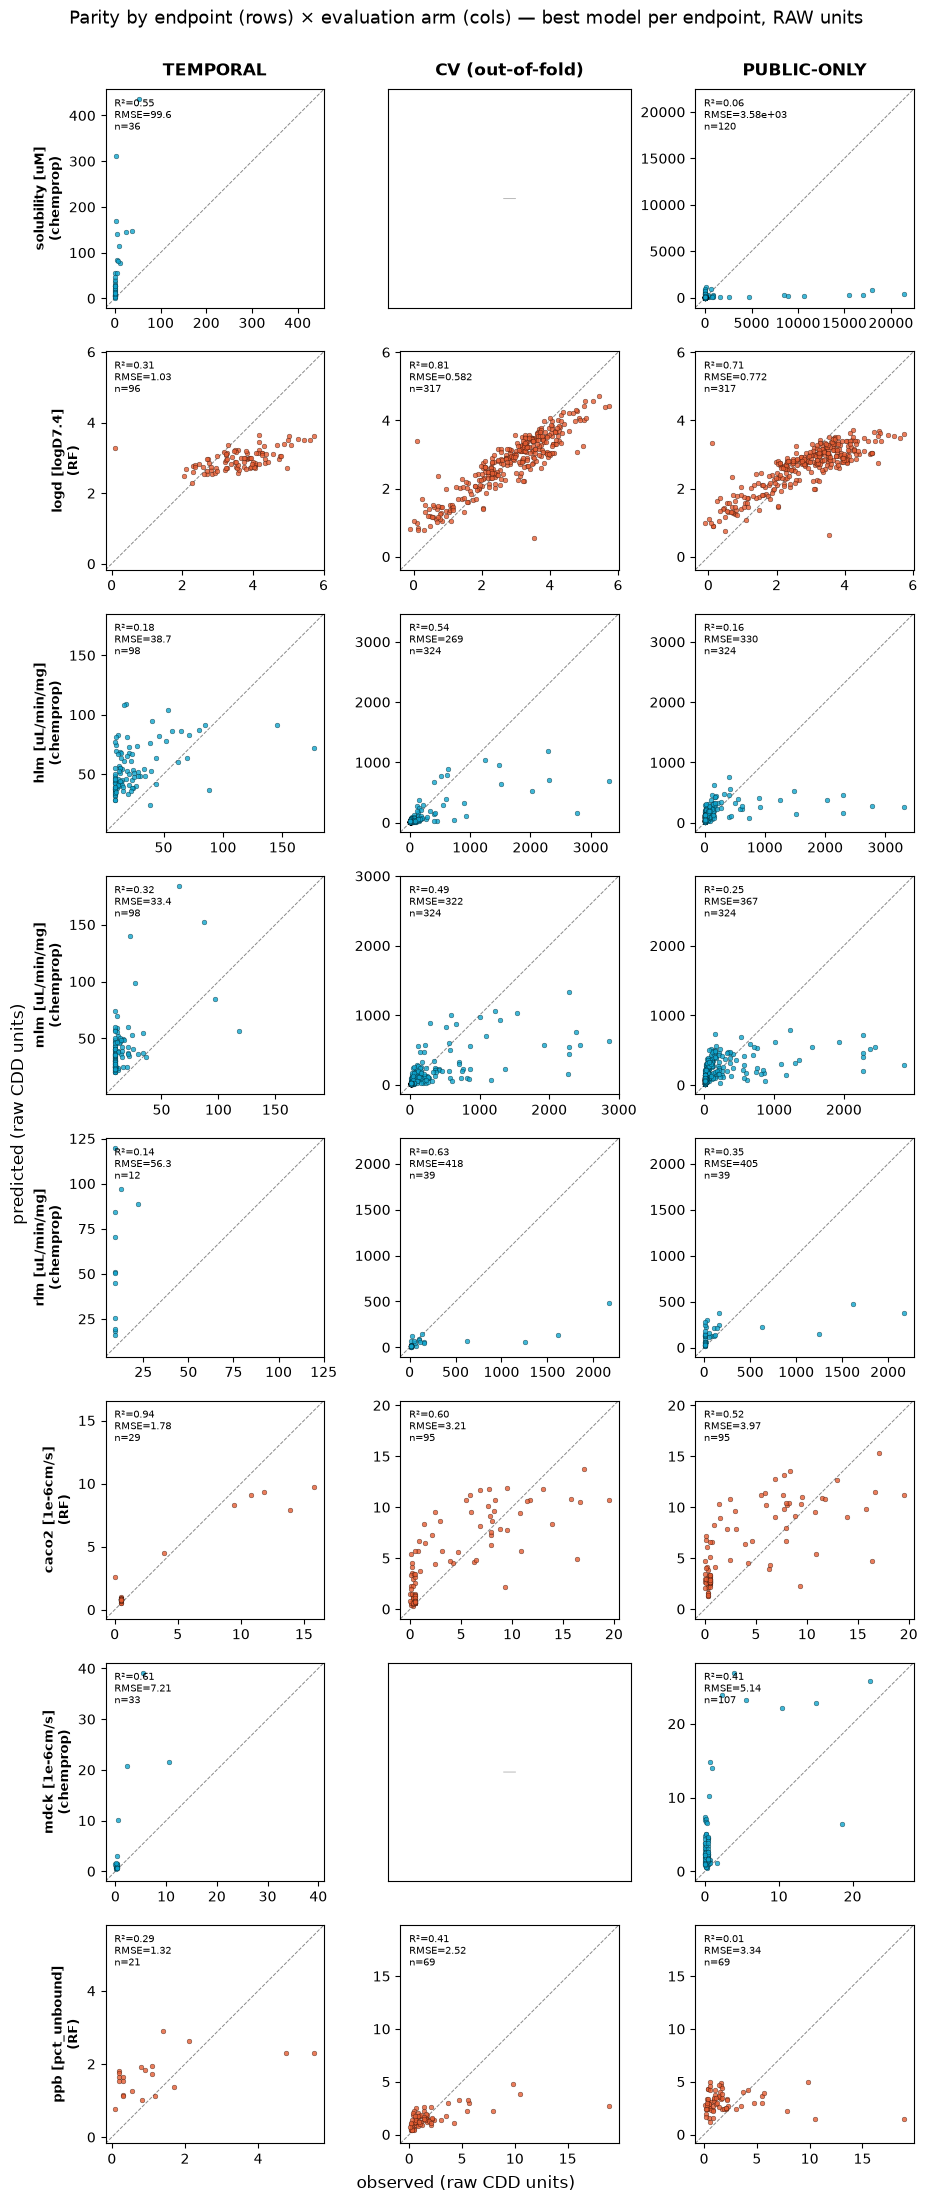

In [15]:
## parity grid: endpoint (rows) x evaluation arm (cols) — best model per endpoint, RAW CDD units
cfg = yaml.safe_load(open('config/config.yaml')); palette = cfg['SERAC_C']; EPCFG = cfg['ADME_ENDPOINTS']
winners = cfg['PUBLIC_TO_INTERNAL']['winners']                       # best model/grouping per endpoint
ADME8, ARMS = ['solubility', 'logd', 'hlm', 'mlm', 'rlm', 'caco2', 'mdck', 'ppb'], ['temporal', 'cv', 'public_only']
ARM_LABEL = {'temporal': 'TEMPORAL', 'cv': 'CV (out-of-fold)', 'public_only': 'PUBLIC-ONLY'}
INV = {'identity': lambda y: y, 'log10': lambda y: 10.0 ** y, 'logit_pct': lambda y: 100.0 / (1.0 + 10.0 ** (-y))}

def _path(ep, arm):                                                  # -> (parquet path, color) for the endpoint's best model
    w = winners[ep]
    if w['model'] == 'chemprop':
        tag = {'temporal': 'temporal', 'cv': 'cv', 'public_only': 'publiconly'}[arm]
        return f"output/predictions_runs_chemprop/{ep}/pred_{w['grouping']}_{tag}.parquet", palette['azure']
    if arm == 'public_only':
        return f'output/predictions_runs/{ep}/pred_public_only.parquet', palette['ember']
    a = 'augmented_temporal_noADM' if (ep == 'caco2' and arm == 'temporal') else f'augmented_{arm}'
    return f'output/predictions_runs/{ep}/pred_{a}.parquet', palette['ember']

fig, axes = plt.subplots(len(ADME8), len(ARMS), figsize=(9.5, 22), dpi=100)
for i, ep in enumerate(ADME8):
    t, unit = EPCFG[ep]['transform'], EPCFG[ep]['unit']
    for j, arm in enumerate(ARMS):
        ax = axes[i, j]
        path, color = _path(ep, arm)
        d = pd.read_parquet(path).dropna(subset=['real_y', 'pred_y']) if os.path.exists(path) else pd.DataFrame()
        if len(d) >= 3 and d['real_y'].nunique() > 1:
            yo, yp = INV[t](d['real_y'].to_numpy()), INV[t](d['pred_y'].to_numpy())   # -> raw CDD units
            r2 = stats_tools.rsquared(yo, yp)                        # NOTE: raw-space Pearson r2 is leverage-dominated (see wiki)
            rmse = float(np.sqrt(((yo - yp) ** 2).mean()))
            lo, hi = min(yo.min(), yp.min()), max(yo.max(), yp.max()); pad = 0.05 * (hi - lo) or 0.5; lo, hi = lo - pad, hi + pad
            ax.plot([lo, hi], [lo, hi], '--', lw=0.7, c='#888', zorder=0)
            ax.scatter(yo, yp, s=12, c=color, edgecolor='black', linewidth=0.25, alpha=0.8)
            ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal'); ax.locator_params(axis='both', nbins=5)
            ax.text(0.04, 0.96, f'R\u00b2={r2:.2f}\nRMSE={rmse:.3g}\nn={len(d)}', transform=ax.transAxes, va='top', ha='left', fontsize=7)
        else:
            ax.text(0.5, 0.5, '—' if d.empty else f'n={len(d)}', ha='center', va='center', transform=ax.transAxes, color='#bbb')
            ax.set_xticks([]); ax.set_yticks([])
        if i == 0:
            ax.set_title(ARM_LABEL[arm], fontsize=12, fontweight='bold', pad=10)
        if j == 0:
            m = 'chemprop' if winners[ep]['model'] == 'chemprop' else 'RF'
            ax.set_ylabel(f'{ep} [{unit}]\n({m})', fontsize=9, fontweight='bold')
fig.supxlabel('observed (raw CDD units)', fontsize=12); fig.supylabel('predicted (raw CDD units)', fontsize=12)
fig.suptitle('Parity by endpoint (rows) \u00d7 evaluation arm (cols) — best model per endpoint, RAW units', y=1.002, fontsize=13)
plt.tight_layout(); plt.show()

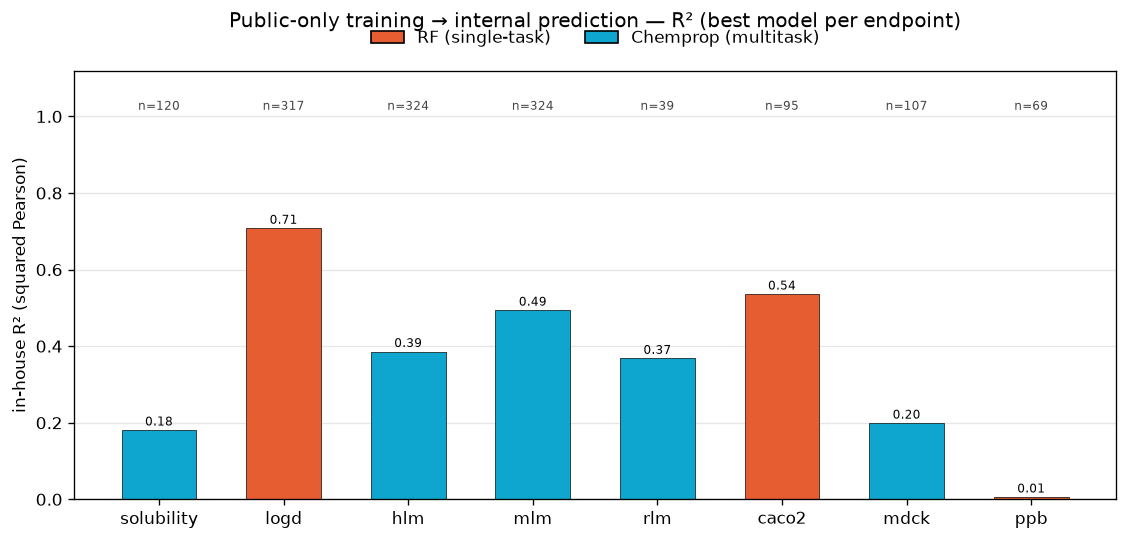

In [8]:
## plotting public training and internal prediction: R2 of the best model/grouping trained on PUBLIC only, predicting ALL internal
import yaml
from matplotlib.patches import Patch
palette = yaml.safe_load(open('config/config.yaml'))['SERAC_C']
res = pd.read_csv('output/predictions_runs/summary_public_to_internal.csv')

colors = [palette['ember'] if w.startswith('RF') else palette['azure'] for w in res['winner']]   # RF vs chemprop
x = np.arange(len(res))
fig, ax = plt.subplots(figsize=(9.5, 4.6), dpi=120)
bars = ax.bar(x, res['publiconly_r2'], 0.6, color=colors, edgecolor='black', linewidth=0.4)
ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=1)
for xi, n in zip(x, res['publiconly_n']):                        # internal compounds predicted (all internal)
    ax.text(xi, 1.01, f'n={int(n)}', ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x); ax.set_xticklabels(res['endpoint'])
ax.set_ylabel('in-house R² (squared Pearson)'); ax.set_ylim(0, 1.12)
ax.set_title('Public-only training → internal prediction — R² (best model per endpoint)', pad=26)
ax.legend(handles=[Patch(facecolor=palette['ember'], edgecolor='black', label='RF (single-task)'),
                   Patch(facecolor=palette['azure'], edgecolor='black', label='Chemprop (multitask)')],
          frameon=False, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.13))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()


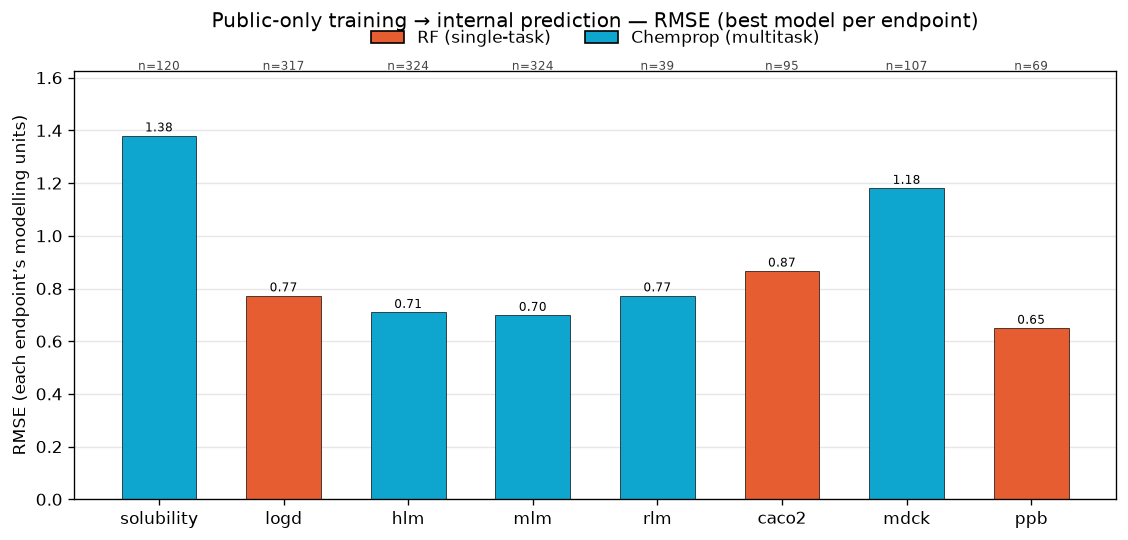

In [9]:
## plotting public training and internal prediction: RMSE of the best model/grouping trained on PUBLIC only, predicting ALL internal
import yaml
from matplotlib.patches import Patch
palette = yaml.safe_load(open('config/config.yaml'))['SERAC_C']
res = pd.read_csv('output/predictions_runs/summary_public_to_internal.csv')

colors = [palette['ember'] if w.startswith('RF') else palette['azure'] for w in res['winner']]   # RF vs chemprop
x = np.arange(len(res))
fig, ax = plt.subplots(figsize=(9.5, 4.6), dpi=120)
bars = ax.bar(x, res['publiconly_rmse'], 0.6, color=colors, edgecolor='black', linewidth=0.4)
ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=1)
top = res['publiconly_rmse'].max() * 1.18
for xi, n in zip(x, res['publiconly_n']):                        # internal compounds predicted (all internal)
    ax.text(xi, top * 0.995, f'n={int(n)}', ha='center', va='bottom', fontsize=7, color='#444')
ax.set_xticks(x); ax.set_xticklabels(res['endpoint'])
ax.set_ylabel('RMSE (each endpoint\u2019s modelling units)'); ax.set_ylim(0, top)
ax.set_title('Public-only training \u2192 internal prediction \u2014 RMSE (best model per endpoint)', pad=26)
ax.legend(handles=[Patch(facecolor=palette['ember'], edgecolor='black', label='RF (single-task)'),
                   Patch(facecolor=palette['azure'], edgecolor='black', label='Chemprop (multitask)')],
          frameon=False, ncol=2, loc='upper center', bbox_to_anchor=(0.5, 1.13))
ax.grid(axis='y', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

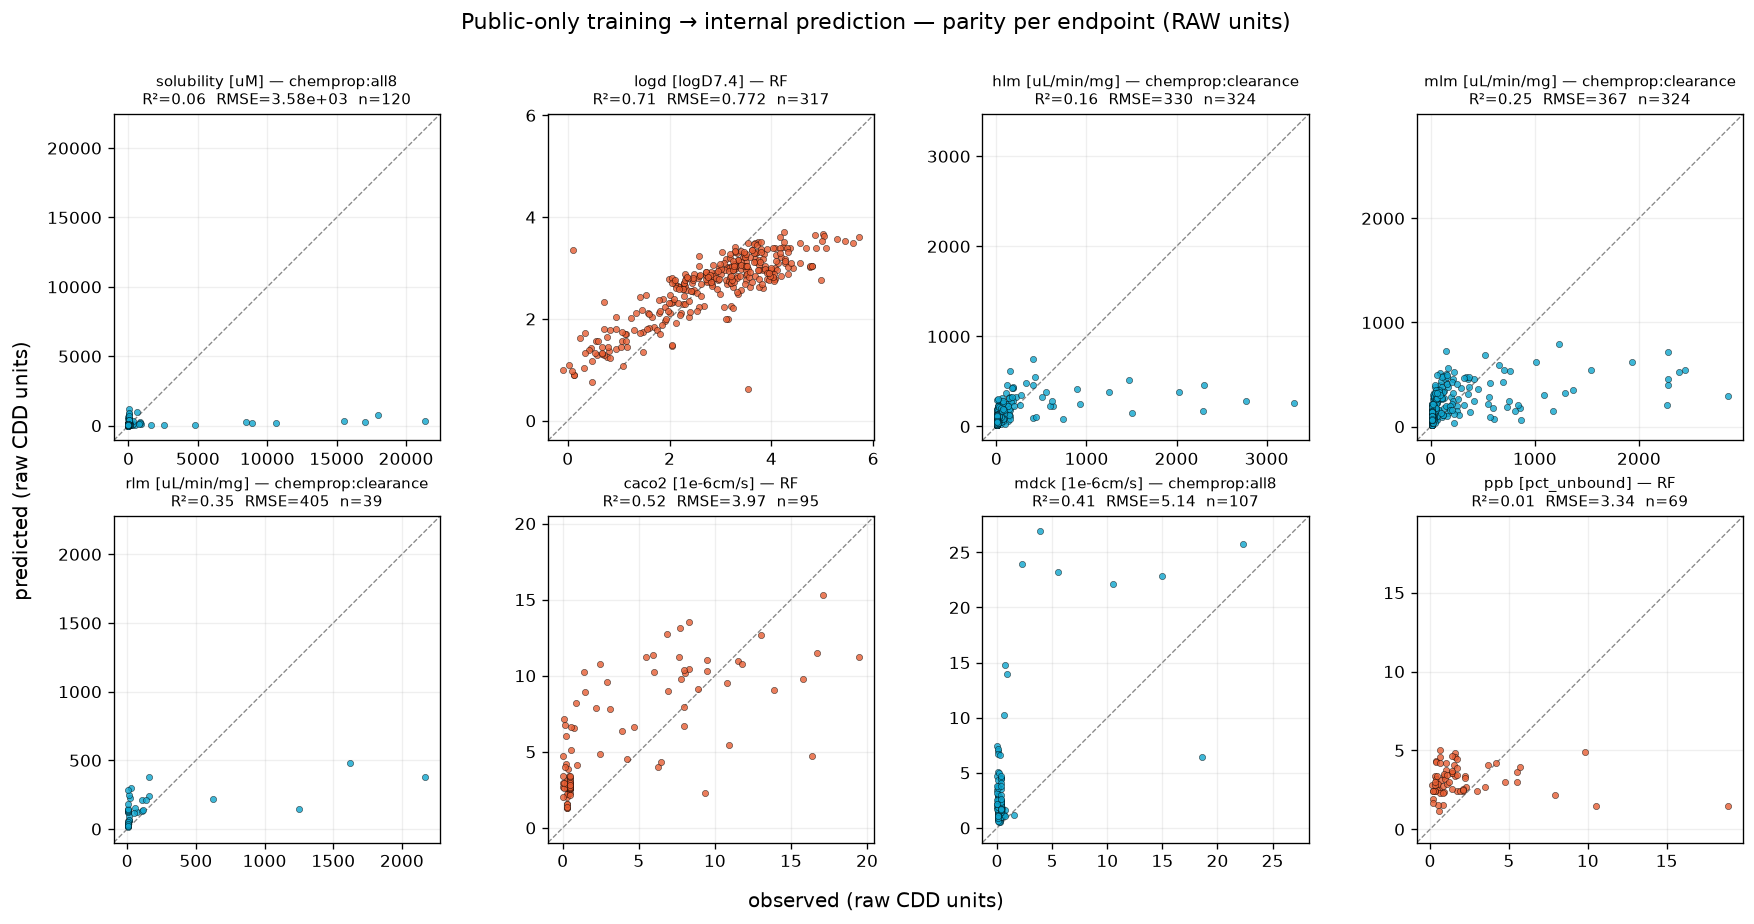

In [14]:
## parity: public-only training -> internal prediction, one panel per endpoint (RAW CDD units)
cfg = yaml.safe_load(open('config/config.yaml')); palette = cfg['SERAC_C']; EPCFG = cfg['ADME_ENDPOINTS']
res = pd.read_csv('output/predictions_runs/summary_public_to_internal.csv')
INV = {'identity': lambda y: y, 'log10': lambda y: 10.0 ** y,       # -> raw CDD unit
       'logit_pct': lambda y: 100.0 / (1.0 + 10.0 ** (-y))}         # -> % unbound

def _pub_path(ep, winner):                                          # winner: 'RF' | 'chemprop:<grouping>'
    if winner == 'RF':
        return f'output/predictions_runs/{ep}/pred_public_only.parquet', palette['ember']
    grp = winner.split(':')[1]
    return f'output/predictions_runs_chemprop/{ep}/pred_{grp}_publiconly.parquet', palette['azure']

fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), dpi=120)
for ax, (_, row) in zip(axes.ravel(), res.iterrows()):
    ep, winner = row['endpoint'], row['winner']
    p, color = _pub_path(ep, winner)
    if not os.path.exists(p):
        ax.text(0.5, 0.5, f'{ep}\n(missing)', ha='center', va='center'); ax.set_axis_off(); continue
    t, unit = EPCFG[ep]['transform'], EPCFG[ep]['unit']
    d = pd.read_parquet(p).dropna(subset=['real_y', 'pred_y'])
    yo, yp = INV[t](d['real_y'].to_numpy()), INV[t](d['pred_y'].to_numpy())   # back to raw units
    r2 = stats_tools.rsquared(yo, yp)                               # NOTE: raw-space Pearson r2 is leverage-dominated (see wiki)
    rmse = float(np.sqrt(((yo - yp) ** 2).mean()))
    lo, hi = min(yo.min(), yp.min()), max(yo.max(), yp.max())
    pad = 0.05 * (hi - lo) or 0.5; lo, hi = lo - pad, hi + pad
    ax.plot([lo, hi], [lo, hi], '--', lw=0.8, c='#888', zorder=0)
    ax.scatter(yo, yp, s=14, c=color, edgecolor='black', linewidth=0.3, alpha=0.8)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
    ax.locator_params(axis='both', nbins=6)                         # round linear ticks (0, 10, 20, ...)
    ax.set_title(f'{ep} [{unit}] — {winner}\nR\u00b2={r2:.2f}  RMSE={rmse:.3g}  n={len(d)}', fontsize=9)
    ax.grid(alpha=0.2); ax.set_axisbelow(True)
fig.supxlabel('observed (raw CDD units)'); fig.supylabel('predicted (raw CDD units)')
fig.suptitle('Public-only training \u2192 internal prediction \u2014 parity per endpoint (RAW units)', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

#### Check models against newest data

In [11]:
## get all protocol data
df_all = get_data(config_path=CONFIG, token_file=TOKEN_FILE)
print('shape:', df_all.shape)
## save a local copy so that Claude can work on it
# df_all.to_csv('data/20260707_all_adme.csv',index=False)

experiments=['caco2', 'hlm', 'logd', 'mdck', 'mlm', 'ppb', 'rlm', 'solubility']
  caco2 (pid=85977): rows=95 compounds=95 readouts=12
  hlm (pid=88861): rows=345 compounds=341 readouts=10
  logd (pid=85979): rows=340 compounds=335 readouts=6
  mdck (pid=131399): rows=133 compounds=131 readouts=26
  mlm (pid=88862): rows=346 compounds=341 readouts=10
  ppb (pid=125963): rows=109 compounds=98 readouts=9
  rlm (pid=111161): rows=39 compounds=39 readouts=10
  solubility (pid=86015): rows=143 compounds=140 readouts=8
compounds=343 columns=102
shape: (343, 102)


In [12]:
## Predict endpoints on new compounds using MLTrail:
from mltrail import Registry
reg = Registry.from_default(); reg_list = reg.list()
ADME = ['solubility', 'logd', 'hlm', 'mlm', 'rlm', 'caco2', 'mdck', 'ppb']

## best model per endpoint (config winner map) -> its registered MLTrail experiment
winners = config.PUBLIC_TO_INTERNAL['winners']
best_name = {ep: (f"adme_mt_{w['grouping']}" if w['model'] == 'chemprop' else f'adme_{ep}') for ep, w in winners.items()}
mid = {ep: int(reg_list.loc[reg_list['experiment_name'] == best_name[ep], 'id'].iloc[0]) for ep in ADME}

## keep only NEW compounds — those not in the internal set the saved models were trained on
seen = set(pd.read_parquet('autoresearch/predict_adme/internal_targets.parquet', columns=['compound'])['compound'])
new = (df_all[[config.ADME_ID_COL, config.ADME_SMILES_COL]]
       .rename(columns={config.ADME_ID_COL: 'compound', config.ADME_SMILES_COL: 'smiles'})
       .dropna().drop_duplicates('compound'))
new = new[~new['compound'].isin(seen)].reset_index(drop=True)
print(f'predicting on {len(new)} new compounds not seen by the saved models')

## invert each endpoint's modelling transform back to its raw CDD assay unit
INV = {'identity':  lambda p: p,                          # logD7.4 (already raw)
       'log10':     lambda p: 10 ** p,                    # uM | uL/min/mg | 1e-6 cm/s
       'logit_pct': lambda p: 100 / (1 + 10 ** (-p))}     # -> % unbound
to_raw = lambda ep, p: INV[config.ADME_ENDPOINTS[ep]['transform']](p)

## predict once per unique model (chemprop returns endpoint-named cols, RF returns "prediction"), in raw units
pred = new[['compound']].copy()
for m in sorted(set(mid.values())):
    out = reg.predict(m, new, smiles_column='smiles', compound_id='compound').set_index('compound')
    for ep in [e for e in ADME if mid[e] == m]:
        p = pred['compound'].map(out[ep] if ep in out.columns else out.select_dtypes('number').iloc[:, -1])
        pred[ep] = to_raw(ep, p)                          # raw CDD assay unit
# pred.to_csv('output/predictions_runs/new_compound_predictions_raw.csv', index=False)
pred

predicting on 18 new compounds not seen by the saved models


,compound,logd,caco2,ppb,hlm,mlm,rlm,solubility,mdck
0,SRB-0007371,4.700334,3.102184,7.245261,107.916114,69.937499,73.758266,42.961635,6.085849
1,SRB-0008008,2.733692,0.688477,1.861017,41.503775,28.859055,32.191076,82.134081,0.853036
2,SRB-0008736,3.870049,0.779776,1.736416,42.578622,31.694441,36.996156,16.140374,1.167227
3,SRB-0010889,3.197618,2.241707,2.764266,77.284873,60.447174,57.316360,424.608809,0.639178
4,SRB-0010891,3.206166,1.715239,1.502673,30.846451,20.358164,23.453858,175.861713,1.082434
5,SRB-0010904,2.701501,2.502374,3.960209,28.331026,33.956796,37.621421,21.257515,5.955581
6,SRB-0011074,2.904486,2.095094,3.401880,47.703616,39.652064,38.390750,496.380372,0.666466
7,SRB-0011388,4.073840,0.842974,1.594679,50.230326,42.369701,47.532844,12.517635,1.711819
8,SRB-0011519,2.914798,2.921093,2.920583,50.363662,61.519529,68.161353,33.864347,10.859222
9,SRB-0011529,3.253808,0.683398,0.924629,52.392316,43.001925,46.593217,32.441304,1.265233


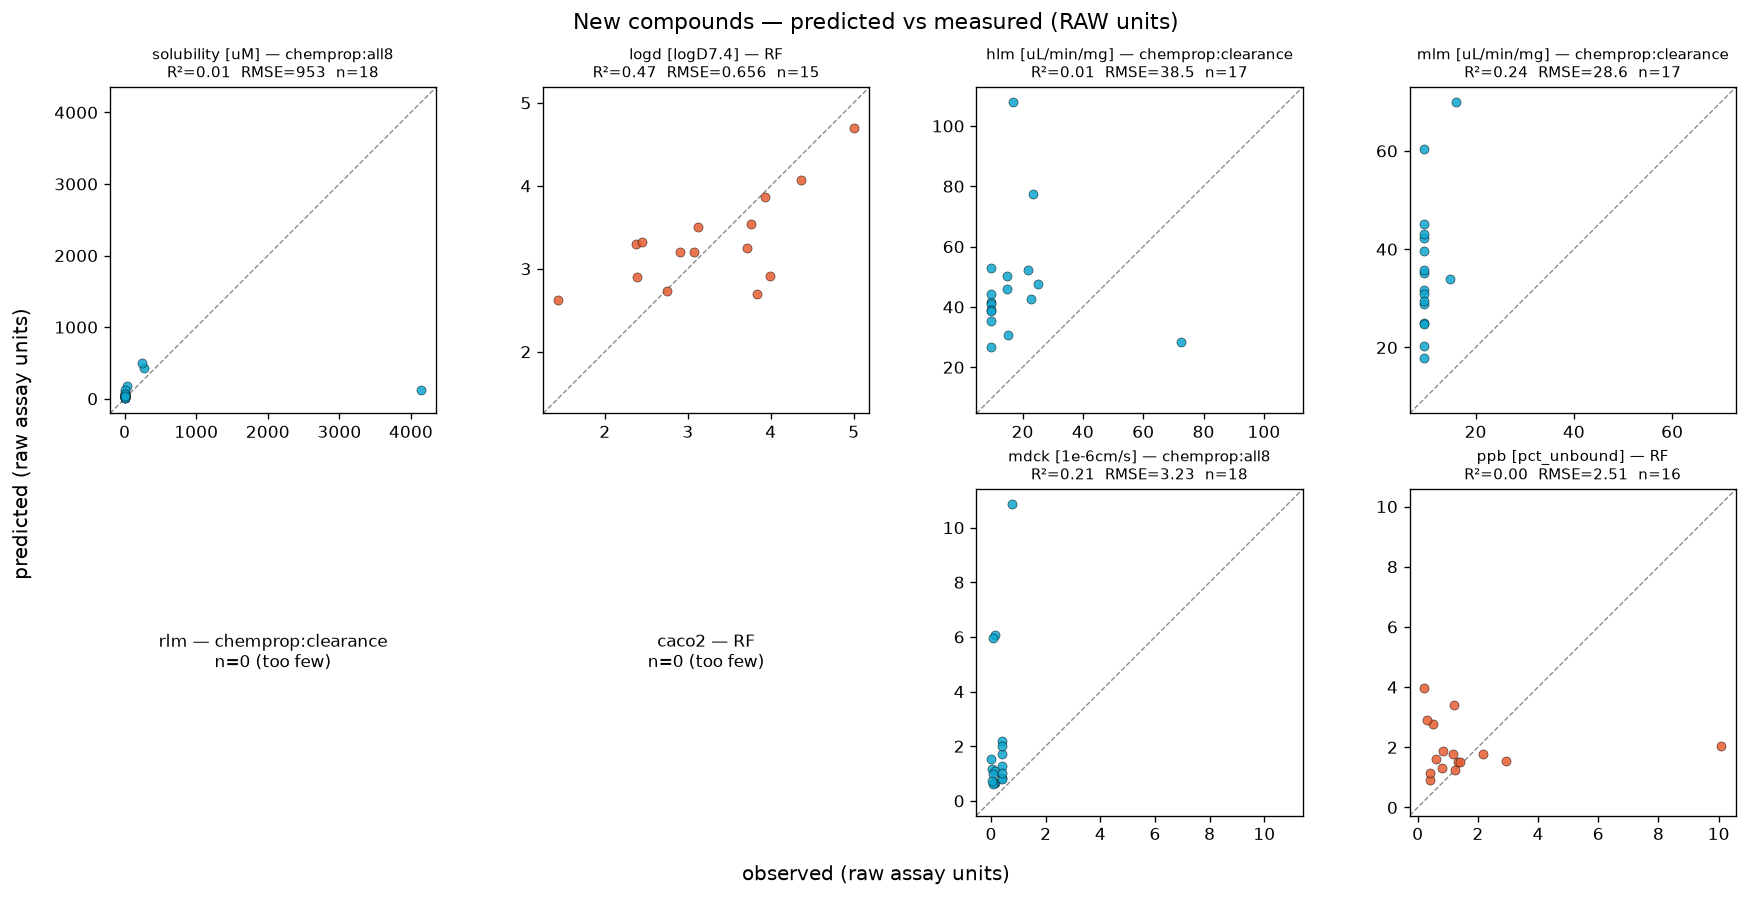

,endpoint,model,unit,n,R2_raw,RMSE_raw
0,solubility,chemprop:all8,uM,18,0.012,953.000
1,logd,RF,logD7.4,15,0.473,0.656
2,hlm,chemprop:clearance,uL/min/mg,17,0.008,38.500
3,mlm,chemprop:clearance,uL/min/mg,17,0.243,28.600
4,rlm,chemprop:clearance,uL/min/mg,0,NaN,NaN
5,caco2,RF,1e-6cm/s,0,NaN,NaN
6,mdck,chemprop:all8,1e-6cm/s,18,0.209,3.230
7,ppb,RF,pct_unbound,16,0.003,2.510


In [13]:
## Validate on the NEW compounds: predicted vs freshly-measured CDD values (RAW assay units, linear axes)
import Statistics_tools as stats_tools
palette = yaml.safe_load(open('config/config.yaml'))['SERAC_C']; EPCFG = config.ADME_ENDPOINTS
UNIT = {ep: EPCFG[ep]['unit'] for ep in ADME}

## observed truth (RAW units): median raw value per compound from the fresh CDD pull, restricted to the new compounds
raw = pd.DataFrame({'compound': df_all[config.ADME_ID_COL].astype(str)})
for ep in ADME:
    raw[ep] = pd.to_numeric(df_all[EPCFG[ep]['col']], errors='coerce') if EPCFG[ep]['col'] in df_all.columns else np.nan
truth = raw.groupby('compound').median(numeric_only=True).reset_index()
truth = truth[truth['compound'].isin(new['compound'])]

## predicted (RAW units) = the `pred` table above (already back-transformed to raw)
rows = []
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5), dpi=120)
for ax, ep in zip(axes.ravel(), ADME):
    is_cp = winners[ep]['model'] == 'chemprop'
    label = f"chemprop:{winners[ep]['grouping']}" if is_cp else 'RF'
    color = palette['azure'] if is_cp else palette['ember']
    d = (truth[['compound', ep]].rename(columns={ep: 'real_y'})
         .merge(pred[['compound', ep]].rename(columns={ep: 'pred_y'}), on='compound').dropna())
    n = len(d)
    if n < 3 or d['real_y'].nunique() < 2:
        ax.text(0.5, 0.5, f'{ep} — {label}\nn={n} (too few)', ha='center', va='center', transform=ax.transAxes); ax.set_axis_off()
        rows.append({'endpoint': ep, 'model': label, 'unit': UNIT[ep], 'n': n, 'R2_raw': np.nan, 'RMSE_raw': np.nan}); continue
    r2 = float(stats_tools.rsquared(d['real_y'], d['pred_y']))       # NOTE: raw-space Pearson r2 is leverage-dominated (see wiki)
    rmse = float(np.sqrt(((d['real_y'] - d['pred_y']) ** 2).mean()))
    rows.append({'endpoint': ep, 'model': label, 'unit': UNIT[ep], 'n': n, 'R2_raw': round(r2, 3), 'RMSE_raw': float(f'{rmse:.3g}')})
    lo, hi = min(d['real_y'].min(), d['pred_y'].min()), max(d['real_y'].max(), d['pred_y'].max())
    pad = 0.05 * (hi - lo) or 0.5; lo, hi = lo - pad, hi + pad
    ax.plot([lo, hi], [lo, hi], '--', lw=0.8, c='#888', zorder=0)
    ax.scatter(d['real_y'], d['pred_y'], s=30, c=color, edgecolor='black', linewidth=0.3, alpha=0.85)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
    ax.locator_params(axis='both', nbins=6)                          # round linear ticks (0, 10, 20, ...) instead of a log scale
    ax.set_title(f'{ep} [{UNIT[ep]}] — {label}\nR\u00b2={r2:.2f}  RMSE={rmse:.3g}  n={n}', fontsize=9)
fig.supxlabel('observed (raw assay units)'); fig.supylabel('predicted (raw assay units)')
fig.suptitle('New compounds \u2014 predicted vs measured (RAW units)', fontsize=13)
plt.tight_layout(); plt.show()
pd.DataFrame(rows)

###  2026-07-21 Data Analysis - Cleaned up experimental dataset

In [4]:
CUTOFFS = {  # raw units; sign in comment. Conventions, not hard rules — see caveats
  'solubility': 10,    # µM,        >= soluble
  'logd':       3,     # logD7.4,   <= within sweet-spot upper bound (>3 = too lipophilic)
  'caco2':      10,    # 1e-6 cm/s, >= high permeability (fa~0.8-0.9)
  'mdck':       10,    # 1e-6 cm/s, >= high permeability
  'ppb':        1,     # % unbound, <= 1  => highly bound (fu<=0.01)
  'hlm':        12,    # µL/min/mg, < 12  => low clearance/stable  (WEAK: measurement floor, no verified triage cutoff)
  'mlm':        12,    # µL/min/mg, same caveat (mouse)
  'rlm':        12,    # µL/min/mg, same caveat (rat)
}

In [5]:
## Summary RF table: CV cleaning-sweep + rolling-origin temporal reconciliation (2026-07-21)
import pandas as pd
summary_rf = pd.DataFrame([
    ['solubility', 0.652, 0.711, 0.727, 0.717, 'EXP-thermo (0.599)', '✓ agree',    '[EXP] thermo (done)'],
    ['logd',       0.766, 0.801, 0.805, 0.809, 'all-source (0.778)', '✗ conflict', 'internal-only (low-conf)'],
    ['hlm',        0.380, 0.538, 0.476, 0.556, 'EXP (0.528)',        '✗ flip',     '[EXP]'],
    ['mlm',        0.455, 0.610, 0.541, 0.627, 'internal (0.605)',   '✓ agree',    'internal-only'],
    ['rlm',       -0.149, 0.234, 0.324, 0.284, 'EXP (0.608)',        '✓ agree',    '[EXP]'],
    ['caco2',      0.262, 0.733, 0.545, 0.744, 'internal (0.478)',   '✓ agree',    'internal-only'],
    ['mdck',       0.088, 0.479, 0.424, 0.479, 'internal (0.507)',   '✓ agree',    'internal-only'],
    ['ppb',        0.385, 0.481, 0.458, 0.489, 'EXP (0.428)',        '✓ agree',    '[EXP]'],
], columns=['endpoint','prxev R²det','new R²det','prev R²','new R²','temporal winner (RMSE)','CV↔temporal','reconciled policy'])
summary_rf


,endpoint,prxev R²det,new R²det,prev R²,new R²,temporal winner (RMSE),CV↔temporal,reconciled policy
0,solubility,0.652,0.711,0.727,0.717,EXP-thermo (0.599),✓ agree,[EXP] thermo (done)
1,logd,0.766,0.801,0.805,0.809,all-source (0.778),✗ conflict,internal-only (low-conf)
2,hlm,0.380,0.538,0.476,0.556,EXP (0.528),✗ flip,[EXP]
3,mlm,0.455,0.610,0.541,0.627,internal (0.605),✓ agree,internal-only
4,rlm,-0.149,0.234,0.324,0.284,EXP (0.608),✓ agree,[EXP]
5,caco2,0.262,0.733,0.545,0.744,internal (0.478),✓ agree,internal-only
6,mdck,0.088,0.479,0.424,0.479,internal (0.507),✓ agree,internal-only
7,ppb,0.385,0.481,0.458,0.489,EXP (0.428),✓ agree,[EXP]


#### 1. Solubility

In [6]:
## load prediction dfs: solubility — CV (cleaning sweep, log10 µM) + ROLLING-ORIGIN temporal (temporal_eval, incl. NN-dist/scaffold)
SOL_SWEEP='output/predictions_runs_solsweep'; SOL_TEMP='output/predictions_runs_temporal/solubility'
RAW_VALUES = 1
pred_sol = {
    'EXP_thermo_cv':          pd.read_parquet(f'{SOL_SWEEP}/S2_thermo/pred_augmented_cv.parquet'),        # 5-fold CV out-of-fold
    'internal_cv':            pd.read_parquet('output/predictions_runs/solubility/pred_internal_cv.parquet'),  # internal-only CV
    'contaminated_cv':        pd.read_parquet(f'{SOL_SWEEP}/S0_contaminated/pred_augmented_cv.parquet'),  # old thermo+kinetic CV (for contrast)
    'temporalRolling_EXP_thermo':    pd.read_parquet(f'{SOL_TEMP}/rolling_previous_deployed.parquet'),           # rolling-origin: train 50->test 50-60, 60->60-70, ... pooled
    'temporalRolling_internal': pd.read_parquet(f'{SOL_TEMP}/rolling_internal_only.parquet'),               # rolling-origin, no public
}
for _ff in sorted(glob(f'output/predictions_runs_temporal_fractions/solubility/f*')):   # temporal fraction-split arms (RF + Chemprop)
    _lab = f'temporal{100 - int(os.path.basename(_ff)[1:])}_{os.path.basename(_ff)[1:]}'   # f30 -> temporal70_30
    for _pf in sorted(glob(f'{_ff}/*.parquet')):
        pred_sol[f'{_lab}_{os.path.basename(_pf)[:-8]}'] = pd.read_parquet(_pf)
for _k, _d in pred_sol.items():
    if RAW_VALUES:
        _d['real_y'] = 10.0 ** _d['real_y']; _d['pred_y'] = 10.0 ** _d['pred_y']   # back-transform: log10 µM -> raw µM
    # print(f'{_k:24} n={len(_d):4}  cols={list(_d.columns)}')

## Summary metrics sol: reusable per-endpoint metrics table (best per col = bold cyan, worst = orange)
from IPython.display import HTML, display
from sklearn import metrics as _m

# per-endpoint classification sign (positive class), back-transform key, and (raw, modelling) unit labels
_EP_SIGN = {'solubility': '>=', 'logd': '<', 'hlm': '<', 'mlm': '<', 'rlm': '<', 'caco2': '>=', 'mdck': '>=', 'ppb': '<'}
_EP_TF   = {'solubility': 'log10', 'logd': 'identity', 'hlm': 'log10', 'mlm': 'log10', 'rlm': 'log10', 'caco2': 'log10', 'mdck': 'log10', 'ppb': 'logit_pct'}
_EP_UNIT = {'solubility': ('µM', 'log10 µM'), 'logd': ('logD7.4', 'logD7.4'), 'hlm': ('µL/min/mg', 'log10'), 'mlm': ('µL/min/mg', 'log10'),
            'rlm': ('µL/min/mg', 'log10'), 'caco2': ('1e-6 cm/s', 'log10'), 'mdck': ('1e-6 cm/s', 'log10'), 'ppb': ('% unbound', 'logit')}
_HIGHER = {'R2_det', 'R2_pears', 'Accuracy', 'PPV', 'NPV', 'F1(+)', 'F1(-)', 'MCC'}; _LOWER = {'RMSE'}   # N, n_train, source unscored
_COLS = ['source', 'R2_det', 'R2_pears', 'RMSE', 'N', 'n_train', 'Accuracy', 'PPV', 'NPV', 'F1(+)', 'F1(-)', 'MCC']
_CNT = {}   # (endpoint,key)->(n_train, source): CV/rolling/fraction provenance (adme_train_counts + build_fraction_counts)
for _cf in ['output/train_counts.csv', 'output/train_counts_fractions.csv']:
    if os.path.exists(_cf):
        _t = pd.read_csv(_cf); _sc = 'providers' if 'providers' in _t.columns else 'source'
        for _r in _t.itertuples():
            _CNT[(_r.endpoint, _r.key)] = (int(_r.n_train), getattr(_r, _sc))

def _to_model(raw, tf):   # raw units -> modelling space (for the cutoff when RAW_VALUES is off)
    if tf == 'log10':     return np.log10(raw)
    if tf == 'logit_pct': return np.log10(raw / (100.0 - raw))
    return raw
def _fmt(c, v):
    if c in ('N', 'n_train'): return 'nan' if pd.isna(v) else f'{int(v)}'
    if c == 'source':         return str(v)
    return 'nan' if pd.isna(v) else f'{v:.3g}'

def endpoint_metrics_table(pred_dict, endpoint, *, raw_values=RAW_VALUES):
    """Regression (R2det/R2pears/RMSE/N) + classification metrics for every pred_df of one endpoint.

    Classification uses CUTOFFS[endpoint] with the endpoint's convention sign; cutoff is taken in raw units
    when raw_values else back-transformed to modelling space. Displays an HTML table (best per column in
    bold cyan, worst in orange) and returns the numeric DataFrame.
    """
    sign = _EP_SIGN[endpoint]; ctf = CUTOFFS[endpoint] if raw_values else _to_model(CUTOFFS[endpoint], _EP_TF[endpoint])
    unit = _EP_UNIT[endpoint][0] if raw_values else _EP_UNIT[endpoint][1]
    def _metrics(df):
        d = df.dropna(subset=['real_y', 'pred_y']); yo = d['real_y'].to_numpy(float); yp = d['pred_y'].to_numpy(float)
        sst = ((yo - yo.mean()) ** 2).sum(); rc, pc = (yo < ctf, yp < ctf) if sign == '<' else (yo >= ctf, yp >= ctf)
        return {'R2_det': 1 - ((yo - yp) ** 2).sum() / sst if sst > 0 else np.nan,
                'R2_pears': np.corrcoef(yo, yp)[0, 1] ** 2 if (len(d) > 1 and yo.std() > 0) else np.nan,
                'RMSE': np.sqrt(((yo - yp) ** 2).mean()), 'N': len(d),
                'Accuracy': _m.accuracy_score(rc, pc), 'PPV': _m.precision_score(rc, pc, zero_division=0),
                'NPV': _m.precision_score(~rc, ~pc, zero_division=0), 'F1(+)': _m.f1_score(rc, pc, zero_division=0),
                'F1(-)': _m.f1_score(rc, pc, pos_label=False, zero_division=0),
                'MCC': _m.matthews_corrcoef(rc, pc) if (rc.min() != rc.max() and pc.min() != pc.max()) else np.nan}
    raw = pd.DataFrame({k: _metrics(v) for k, v in pred_dict.items()}).T
    order = [k for k in raw.index if 'temporal' not in k] + [k for k in raw.index if 'temporal' in k]   # CV rows first, temporal after
    raw = raw.loc[order]
    _sig = lambda r: tuple('nan' if pd.isna(x) else round(float(x), 10) for x in r)   # collapse exact-duplicate metric rows
    groups = []; _seen = {}
    for k in raw.index:
        s = _sig(raw.loc[k])
        if s in _seen: groups[_seen[s]][1].append(k)
        else: _seen[s] = len(groups); groups.append((k, [k]))
    def _label(members):   # merge aliased names into one label; mark the reconciled winner
        win = 'cv_winner' in members; ms = [m for m in members if m != 'cv_winner'] or ['cv_winner']
        return ' = '.join(ms) + (' (winner)' if win else '')
    reps = [rep for rep, _ in groups]
    df = pd.DataFrame([raw.loc[r] for r in reps], index=[_label(m) for _, m in groups])
    def _cat(key):   # CV, temporal-rolling, then fraction cuts (80/20, 70/30, 60/40)
        k = key.lower()
        if 'temporal' not in k: return (0, 'CV')
        if 'rolling' in k:      return (1, 'temporal-rolling')
        for j, tag in enumerate(['80_20', '70_30', '60_40'], start=2):
            if f'temporal{tag}' in k: return (j, 'temporal ' + tag.replace('_', '/'))
        return (5, 'temporal-other')
    df['_ci'] = [_cat(r)[0] for r in reps]; df['_cn'] = [_cat(r)[1] for r in reps]
    df = df.sort_values(['_ci', 'R2_det'], ascending=[True, False])       # category order, then R2det desc within
    members_by_label = {_label(m): m for _, m in groups}
    def _lk(label):
        for k in members_by_label.get(label, []):
            if (endpoint, k) in _CNT: return _CNT[(endpoint, k)]
        return (np.nan, '?')
    df['n_train'] = [_lk(l)[0] for l in df.index]; df['source'] = [_lk(l)[1] for l in df.index]
    ci = df['_ci'].to_numpy(); cn = df['_cn'].to_numpy(); df = df[_COLS]
    def _bw(sub):
        b, w = {}, {}
        for c in sub.columns:
            if c in _HIGHER:  b[c], w[c] = sub[c].max(), sub[c].min()
            elif c in _LOWER: b[c], w[c] = sub[c].min(), sub[c].max()
        return b, w
    bws = {c: _bw(df[ci == c]) for c in set(ci)}                          # best/worst WITHIN each category
    CY, OR = '#0097A7', '#F57C00'
    def _td(c, v, bw, sep=''):
        best, worst = bw; s = _fmt(c, v); base = f'text-align:{"left" if c == "source" else "right"};padding:2px 8px{sep}'
        if c in best and not pd.isna(v):
            if v == best[c]:                              return f'<td style="color:{CY};font-weight:700;{base}">{s}</td>'
            if v == worst[c] and worst[c] != best[c]:     return f'<td style="color:{OR};{base}">{s}</td>'
        return f'<td style="{base}">{s}</td>'
    th = ''.join(f'<th style="text-align:right;padding:2px 8px;border-bottom:1px solid #999">{c}</th>' for c in df.columns)
    body = ''
    for i, (k, r) in enumerate(df.iterrows()):
        sep = ';border-top:3px double #666' if (i > 0 and ci[i] != ci[i - 1]) else ''   # double rule between categories
        body += (f'<tr><td style="text-align:left;font-weight:600;padding:2px 8px{sep}">{k}</td>' +
                 ''.join(_td(c, r[c], bws[ci[i]], sep) for c in df.columns) + '</tr>')
    cap = (f'<b>{endpoint}</b> — all prediction results · cutoff {CUTOFFS[endpoint]:g} {unit} (sign {sign}) · '
           f'<span style="color:{CY};font-weight:700">best</span>/<span style="color:{OR}">worst</span> per column, within each category (double rule = category boundary)')
    display(HTML(f'<div style="font:13px sans-serif"><p>{cap}</p><table style="border-collapse:collapse">'
                 f'<thead><tr><th style="text-align:left;padding:2px 8px;border-bottom:1px solid #999">pred_df</th>{th}</tr></thead>'
                 f'<tbody>{body}</tbody></table></div>'))
    return df

sol_summary = endpoint_metrics_table(pred_sol, 'solubility')


pred_df,source,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
EXP_thermo_cv,PharmaBench/ChEMBL/Biogen(+),0.536,0.677,2.41e+03,120,17989,0.825,0.698,0.896,0.741,0.868,0.612
internal_cv,internal only,0.379,0.717,2.78e+03,120,120,0.85,0.738,0.91,0.775,0.887,0.665
contaminated_cv,mixed (pre-cleanup),-0.0169,0.791,3.56e+03,120,106427,0.842,0.702,0.932,0.776,0.877,0.665
temporalRolling_EXP_thermo,PharmaBench/ChEMBL/Biogen(+),-0.014,0.00475,78.4,60,17985,0.833,0.143,0.925,0.167,0.907,0.0783
temporalRolling_internal,internal only,-0.411,3.02e-05,92.5,60,108,0.817,0.2,0.94,0.267,0.895,0.189
temporal80_20_cp_EXP,PharmaBench/ChEMBL/Biogen(+),-0.205,0.0105,9.29,24,18148,0.875,0,0.913,0,0.933,-0.0629
temporal80_20_rf_EXP,PharmaBench/ChEMBL/Biogen(+),-3.22,0.0155,17.4,24,17973,0.792,0,0.905,0,0.884,-0.114
temporal80_20_rf_internal,internal only,-18.8,0.0149,37.7,24,96,0.792,0,0.905,0,0.884,-0.114
temporal70_30_rf_EXP,PharmaBench/ChEMBL/Biogen(+),-0.802,0.255,14.4,36,17961,0.778,0.167,0.9,0.2,0.871,0.0791
temporal70_30_cp_EXP,PharmaBench/ChEMBL/Biogen(+),-1.94,0.258,18.4,36,18138,0.806,0.2,0.903,0.222,0.889,0.114


In [27]:
sel_pred_df = pred_sol['temporal70_30_cp_EXP']   # selected pred_df carried to downstream analysis cells (repoint as needed)

<Axes: title={'center': 'Solubility CV out-of-fold — EXP-thermo augmentation\nR²=0.52  R²det=-8.53  RMSE=33.1  n=36'}, xlabel='observed [µM]', ylabel='predicted [µM]'>

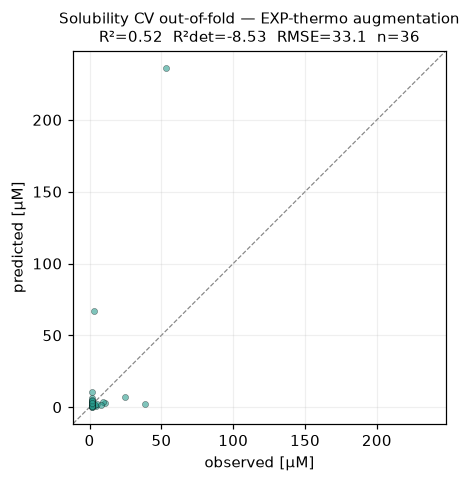

In [28]:
## show CV parity plot of EXP thermo
# pred_df = pred_sol['EXP_thermo_temporal'].copy()
# pred_df = pred_df[pred_df['nn_tanimoto_dist'] < 0.2]
ML_Reg.plot_parity_from_pred_df(sel_pred_df,
    title='Solubility CV out-of-fold — EXP-thermo augmentation',
    unit=('µM' if RAW_VALUES else 'log10 µM'), color='#2A9D8F', alpha=0.6)

In [53]:
## get classification metrics from pred_df - soluble vs insoluble at CUTOFF_SOL µM (RAW_VALUES-aware cutoff)
_ctf = 15 if RAW_VALUES else np.log10(CUTOFF_SOL)   # real_y/pred_y are µM if RAW_VALUES else log10 µM
print(f'Solubility — soluble at >= {CUTOFF_SOL} µM  (cutoff on {"µM" if RAW_VALUES else "log10 µM"} = {_ctf:g})')
f1, ppv, cm, pred_sol_labeled = ML_Class.classification_from_regression_pred(
    sel_pred_df, ctf_pred=_ctf, sign='>=', return_labels=True)
pred_sol_labeled[['compound', 'real_y', 'pred_y', 'real_class', 'pred_class']].head()

Solubility — soluble at >= 10 µM  (cutoff on µM = 15)
> accuracy: 0.89, precision(PPV): 0.79, NPV: 0.94, F1(+): 0.82, F1(-): 0.92, MCC: 0.75
               pred_neg pred_pos    total
  real_neg           77        8       85
  real_pos            5       30       35
  total              82       38      120


,compound,real_y,pred_y,real_class,pred_class
0,SRB-0000069,466.00,116.098320,True,True
1,SRB-0000133,849.00,5691.253957,True,True
2,SRB-0000433,21371.00,4386.265091,True,True
3,SRB-0000862,8.97,25.116544,False,True
4,SRB-0001864,220.00,105.337072,True,True


#### 2. LogD


In [ ]:
## load prediction dfs: LogD — internal CV + every augmentation source-combo (CV) + ALL rolling-origin temporal arms; RAW_VALUES-aware (identity)
## keys: cv_<sources> (sources: EXP+NVS+ADM) + temporal_{deployed=config policy / EXP=experimental-only / internal}; S2_exp_only collapses to 'internal' when no EXP
_SW='output/predictions_runs_admesweep/logd'; _TE='output/predictions_runs_temporal/logd'; _INV = lambda y: y
_LBL = {'S0_all_raw': 'all', 'S1_all_phys': 'all_clip', 'S2_exp_only': 'EXP', 'S3_drop_adm': 'EXP_NVS', 'S4_best_combo': 'EXP_NVS_clean', 'S5_internal_only': 'internal'}   # sweep-strategy dir -> source-composition label
_TMAP = {'internal_only':'internal', 'previous_deployed':'deployed', 'experimental':'EXP'}
pred_logd = {'internal_cv': pd.read_parquet('output/predictions_runs/logd/pred_internal_cv.parquet')}
for _sd in sorted(glob(f'{_SW}/*/')):
    pred_logd['cv_'+_LBL.get(os.path.basename(_sd.rstrip('/')), os.path.basename(_sd.rstrip('/')))] = pd.read_parquet(f'{_sd}pred_augmented_cv.parquet')
for _tf in sorted(glob(f'{_TE}/rolling_*.parquet')):
    _t = os.path.basename(_tf).replace('rolling_','').replace('.parquet','')
    pred_logd['temporalRolling_'+_TMAP.get(_t, _t)] = pd.read_parquet(_tf)
for _ff in sorted(glob(f'output/predictions_runs_temporal_fractions/logd/f*')):   # temporal fraction-split arms (RF + Chemprop)
    _lab = f'temporal{100 - int(os.path.basename(_ff)[1:])}_{os.path.basename(_ff)[1:]}'   # f30 -> temporal70_30
    for _pf in sorted(glob(f'{_ff}/*.parquet')):
        pred_logd[f'{_lab}_{os.path.basename(_pf)[:-8]}'] = pd.read_parquet(_pf)
for _k, _d in pred_logd.items():
    if RAW_VALUES: _d['real_y']=_INV(_d['real_y']); _d['pred_y']=_INV(_d['pred_y'])
    # print(f'{_k:22} n={len(_d):4}  cols={list(_d.columns)}')
pred_logd['cv_winner'] = pred_logd['cv_internal']                       # reconciled CV winner (alias; parity/classification use this)
                       # selected pred_df carried to downstream analysis cells (repoint as needed)

## Summary metrics logd: regression + classification for every pred_df (best per col = bold cyan, worst = orange; double rule = CV | temporal)
logd_summary = endpoint_metrics_table(pred_logd, 'logd')

pred_df,source,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
internal_cv = cv_internal (winner),internal only,0.801,0.809,0.537,317,317,0.874,0.868,0.88,0.868,0.88,0.747
cv_EXP,AstraZeneca,0.793,0.805,0.547,317,4517,0.864,0.821,0.913,0.865,0.863,0.734
cv_EXP_NVS_clean,AstraZeneca + Novartis,0.786,0.804,0.556,317,44445,0.842,0.789,0.908,0.847,0.838,0.694
cv_all_clip,AstraZeneca + Novartis + ADMETlab,0.784,0.811,0.558,317,84512,0.852,0.802,0.91,0.854,0.849,0.711
cv_all,AstraZeneca + Novartis + ADMETlab,0.784,0.812,0.559,317,84517,0.858,0.812,0.912,0.86,0.856,0.722
cv_EXP_NVS,AstraZeneca + Novartis,0.782,0.798,0.562,317,44512,0.845,0.793,0.909,0.849,0.841,0.7
temporalRolling_deployed,AstraZeneca + Novartis + ADMETlab,0.596,0.671,0.778,159,40285,0.83,0.765,0.905,0.828,0.832,0.672
temporalRolling_internal,internal only,0.524,0.539,0.845,159,285,0.805,0.781,0.826,0.786,0.821,0.607
temporalRolling_EXP,AstraZeneca,0.497,0.607,0.868,159,4485,0.774,0.684,0.918,0.788,0.757,0.588
temporal80_20_rf_internal,internal only,-0.153,0.313,0.731,64,253,0.906,0.6,0.932,0.5,0.948,0.458


In [31]:
sel_pred_df = pred_logd['temporalRolling_deployed'] 

<Axes: title={'center': 'LogD CV out-of-fold — internal-only\nR²=0.67  R²det=0.60  RMSE=0.778  n=159'}, xlabel='observed [logD7.4]', ylabel='predicted [logD7.4]'>

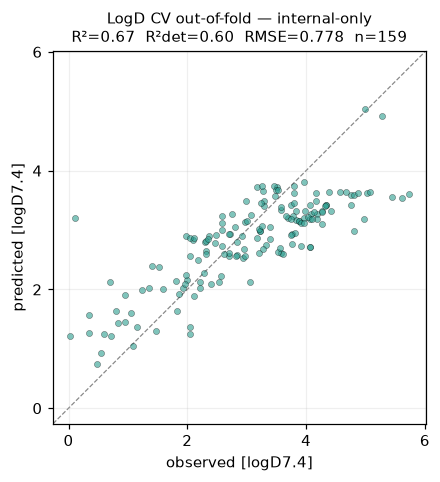

In [32]:
## show CV parity plot of the winner (internal-only)
ML_Reg.plot_parity_from_pred_df(sel_pred_df, title='LogD CV out-of-fold — internal-only',
    unit=('logD7.4' if RAW_VALUES else 'logD7.4'), color='#2A9D8F', alpha=0.6)


In [ ]:
## get classification metrics from pred_df - LogD  (cutoff = cv_winner median = placeholder 50/50 split; SET a domain cutoff in raw units)
_ctf = pred_logd['cv_winner']['real_y'].median()
_f1, _ppv, _cm, pred_logd_labeled = ML_Class.classification_from_regression_pred(pred_logd['cv_winner'], ctf_pred=_ctf, sign='>=', return_labels=True)
pred_logd_labeled[['compound','real_y','pred_y','real_class','pred_class']].head()


#### 3. HLM


In [12]:
## load prediction dfs: HLM — internal CV + every augmentation source-combo (CV) + ALL rolling-origin temporal arms; RAW_VALUES-aware (log10)
## keys: cv_<sources> (sources: EXP+NVS) + temporal_{deployed=config policy / EXP=experimental-only / internal}; S2_exp_only collapses to 'internal' when no EXP
_SW='output/predictions_runs_admesweep/hlm'; _TE='output/predictions_runs_temporal/hlm'; _INV = lambda y: 10.0**y
_LBL = {'S0_all_raw': 'EXP_NVS', 'S1_all_phys': 'EXP_NVS_clip', 'S2_exp_only': 'EXP', 'S4_best_combo': 'EXP_NVS_clean', 'S5_internal_only': 'internal'}   # sweep-strategy dir -> source-composition label
_TMAP = {'internal_only':'internal', 'previous_deployed':'deployed', 'experimental':'EXP'}
pred_hlm = {'internal_cv': pd.read_parquet('output/predictions_runs/hlm/pred_internal_cv.parquet')}
for _sd in sorted(glob(f'{_SW}/*/')):
    pred_hlm['cv_'+_LBL.get(os.path.basename(_sd.rstrip('/')), os.path.basename(_sd.rstrip('/')))] = pd.read_parquet(f'{_sd}pred_augmented_cv.parquet')
for _tf in sorted(glob(f'{_TE}/rolling_*.parquet')):
    _t = os.path.basename(_tf).replace('rolling_','').replace('.parquet','')
    pred_hlm['temporalRolling_'+_TMAP.get(_t, _t)] = pd.read_parquet(_tf)
for _ff in sorted(glob(f'output/predictions_runs_temporal_fractions/hlm/f*')):   # temporal fraction-split arms (RF + Chemprop)
    _lab = f'temporal{100 - int(os.path.basename(_ff)[1:])}_{os.path.basename(_ff)[1:]}'   # f30 -> temporal70_30
    for _pf in sorted(glob(f'{_ff}/*.parquet')):
        pred_hlm[f'{_lab}_{os.path.basename(_pf)[:-8]}'] = pd.read_parquet(_pf)
for _k, _d in pred_hlm.items():
    if RAW_VALUES: _d['real_y']=_INV(_d['real_y']); _d['pred_y']=_INV(_d['pred_y'])
    # print(f'{_k:22} n={len(_d):4}  cols={list(_d.columns)}')
pred_hlm['cv_winner'] = pred_hlm['cv_internal']                       # reconciled CV winner (alias; parity/classification use this)

## Summary metrics hlm: regression + classification for every pred_df (best per col = bold cyan, worst = orange; double rule = CV | temporal)
hlm_summary = endpoint_metrics_table(pred_hlm, 'hlm')

pred_df,source,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
internal_cv = cv_internal (winner),internal only,0.292,0.518,300,324,324,0.713,0.9,0.694,0.367,0.814,0.358
cv_EXP_NVS = cv_EXP_NVS_clip,Biogen/AstraZeneca + Novartis,0.145,0.367,330,324,44513,0.642,0.571,0.644,0.0645,0.779,0.0651
cv_EXP_NVS_clean,Biogen/AstraZeneca + Novartis,0.143,0.373,330,324,44460,0.648,0.667,0.648,0.0952,0.782,0.108
cv_EXP,Biogen/AstraZeneca,0.0861,0.358,341,324,4513,0.741,0.902,0.717,0.468,0.829,0.429
temporalRolling_EXP,Biogen/AstraZeneca,0.00461,0.0406,117,162,4480,0.716,0.889,0.706,0.258,0.824,0.29
temporalRolling_deployed,Biogen/AstraZeneca + Novartis,-0.127,0.0995,125,162,40291,0.673,0,0.673,0,0.804,nan
temporalRolling_internal,internal only,-1.36,0.0598,181,162,291,0.685,1,0.681,0.0727,0.81,0.16
temporal80_20_rf_EXP,?,0.227,0.246,22.1,65,nan,0.738,0,0.738,0,0.85,nan
temporal80_20_rf_internal,?,0.185,0.247,22.7,65,nan,0.738,0,0.738,0,0.85,nan
temporal80_20_cp_EXP_NVS,?,0.059,0.174,24.4,65,nan,0.662,0.222,0.732,0.154,0.788,-0.0359


In [115]:
sel_pred_df = pred_hlm['temporal_EXP']                        # selected pred_df carried to downstream analysis cells (repoint as needed)


<Axes: title={'center': 'HLM CV out-of-fold — internal-only\nR²=0.04  R²det=0.00  RMSE=117  n=162'}, xlabel='observed [uL/min/mg]', ylabel='predicted [uL/min/mg]'>

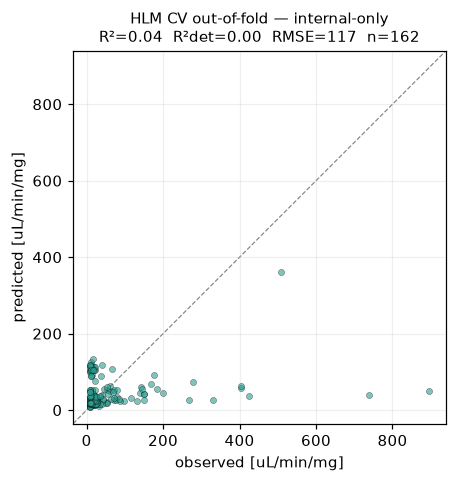

In [116]:
## show CV parity plot of the winner (internal-only)
ML_Reg.plot_parity_from_pred_df(sel_pred_df, title='HLM CV out-of-fold — internal-only',
    unit=('uL/min/mg' if RAW_VALUES else 'log10(uL/min/mg)'), color='#2A9D8F', alpha=0.6)

In [118]:
## get classification metrics from pred_df - HLM  (cutoff = cv_winner median = placeholder 50/50 split; SET a domain cutoff in raw units)
_ctf = 10 # pred_hlm['cv_winner']['real_y'].median()
_f1, _ppv, _cm, pred_hlm_labeled = ML_Class.classification_from_regression_pred(sel_pred_df, ctf_pred=_ctf, sign='>=', return_labels=True)
pred_hlm_labeled[['compound','real_y','pred_y','real_class','pred_class']].head()


> accuracy: 0.73, precision(PPV): 0.73, NPV: 1.00, F1(+): 0.84, F1(-): 0.09, MCC: 0.18
               pred_neg pred_pos    total
  real_neg            2       43       45
  real_pos            0      117      117
  total               2      160      162


,compound,real_y,pred_y,real_class,pred_class
0,SRB-0002030,424.4,35.666477,True,True
1,SRB-0002033,32.1,22.704368,True,True
2,SRB-0002038,18.2,14.039913,True,True
3,SRB-0002045,9.6,12.809151,False,True
4,SRB-0002046,26.6,15.094273,True,True


#### 4. MLM


In [ ]:
## load prediction dfs: MLM — internal CV + every augmentation source-combo (CV) + ALL rolling-origin temporal arms; RAW_VALUES-aware (log10)
## keys: cv_<sources> (sources: NVS) + temporal_{deployed=config policy / EXP=experimental-only / internal}; S2_exp_only collapses to 'internal' when no EXP
_SW='output/predictions_runs_admesweep/mlm'; _TE='output/predictions_runs_temporal/mlm'; _INV = lambda y: 10.0**y
_LBL = {'S0_all_raw': 'NVS', 'S1_all_phys': 'NVS_clip', 'S2_exp_only': 'internal', 'S4_best_combo': 'NVS_clean'}   # sweep-strategy dir -> source-composition label
_TMAP = {'internal_only':'internal', 'previous_deployed':'deployed', 'experimental':'EXP'}
pred_mlm = {'internal_cv': pd.read_parquet('output/predictions_runs/mlm/pred_internal_cv.parquet')}
for _sd in sorted(glob(f'{_SW}/*/')):
    pred_mlm['cv_'+_LBL.get(os.path.basename(_sd.rstrip('/')), os.path.basename(_sd.rstrip('/')))] = pd.read_parquet(f'{_sd}pred_augmented_cv.parquet')
for _tf in sorted(glob(f'{_TE}/rolling_*.parquet')):
    _t = os.path.basename(_tf).replace('rolling_','').replace('.parquet','')
    pred_mlm['temporalRolling_'+_TMAP.get(_t, _t)] = pd.read_parquet(_tf)
for _ff in sorted(glob(f'output/predictions_runs_temporal_fractions/mlm/f*')):   # temporal fraction-split arms (RF + Chemprop)
    _lab = f'temporal{100 - int(os.path.basename(_ff)[1:])}_{os.path.basename(_ff)[1:]}'   # f30 -> temporal70_30
    for _pf in sorted(glob(f'{_ff}/*.parquet')):
        pred_mlm[f'{_lab}_{os.path.basename(_pf)[:-8]}'] = pd.read_parquet(_pf)
for _k, _d in pred_mlm.items():
    if RAW_VALUES: _d['real_y']=_INV(_d['real_y']); _d['pred_y']=_INV(_d['pred_y'])
    # print(f'{_k:22} n={len(_d):4}  cols={list(_d.columns)}')
pred_mlm['cv_winner'] = pred_mlm['cv_internal']                       # reconciled CV winner (alias; parity/classification use this)

## Summary metrics mlm: regression + classification for every pred_df (best per col = bold cyan, worst = orange; double rule = CV | temporal)
mlm_summary = endpoint_metrics_table(pred_mlm, 'mlm')

pred_df,source,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
internal_cv = cv_internal (winner),internal only,0.173,0.427,381,324,324,0.762,0.885,0.734,0.584,0.834,0.498
cv_NVS_clean,Novartis,0.143,0.33,388,324,40323,0.725,0.927,0.696,0.461,0.816,0.426
cv_NVS = cv_NVS_clip,Novartis,0.136,0.304,390,324,40324,0.719,0.923,0.691,0.442,0.812,0.411
temporalRolling_deployed,Novartis,0.0782,0.0949,319,162,40291,0.531,1,0.506,0.174,0.672,0.22
temporalRolling_internal,internal only,-0.0499,0.00411,341,162,291,0.562,0.882,0.524,0.297,0.682,0.249
temporal80_20_rf_internal,?,0.234,0.349,14.2,65,nan,0.415,0.75,0.368,0.24,0.525,0.0814
temporal80_20_cp_NVS,?,-0.927,0.556,22.5,65,nan,0.692,0.958,0.537,0.697,0.688,0.5
temporal80_20_rf_NVS,?,-13.2,0.378,61.1,65,nan,0.369,0.667,0.355,0.0889,0.518,0.00944
temporal70_30_cp_NVS,Novartis,-4.02,0.248,38.4,98,273843,0.327,0,0.327,0,0.492,nan
temporal70_30_rf_internal,internal only,-15.8,0.0262,70.2,98,226,0.327,0,0.327,0,0.492,nan


In [14]:
sel_pred_df = pred_mlm['temporal80_20_cp_NVS']                        # selected pred_df carried to downstream analysis cells (repoint as needed)

<Axes: title={'center': 'MLM CV out-of-fold — internal-only\nR²=0.56  R²det=-0.93  RMSE=22.5  n=65'}, xlabel='observed [uL/min/mg]', ylabel='predicted [uL/min/mg]'>

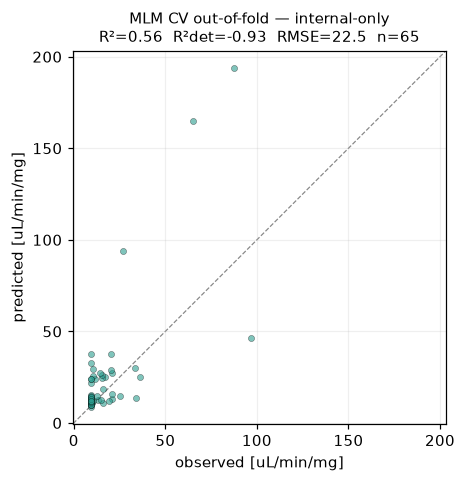

In [15]:
## show CV parity plot of the winner (internal-only)
ML_Reg.plot_parity_from_pred_df(sel_pred_df, title='MLM CV out-of-fold — internal-only',
    unit=('uL/min/mg' if RAW_VALUES else 'log10(uL/min/mg)'), color='#2A9D8F', alpha=0.6)


In [12]:
## get classification metrics from pred_df - MLM  (cutoff = cv_winner median = placeholder 50/50 split; SET a domain cutoff in raw units)
_ctf = pred_mlm['cv_winner']['real_y'].median()
_f1, _ppv, _cm, pred_mlm_labeled = ML_Class.classification_from_regression_pred(pred_mlm['cv_winner'], ctf_pred=_ctf, sign='>=', return_labels=True)
pred_mlm_labeled[['compound','real_y','pred_y','real_class','pred_class']].head()


> accuracy: 0.81, precision(PPV): 0.76, NPV: 0.91, F1(+): 0.83, F1(-): 0.79, MCC: 0.65
               pred_neg pred_pos    total
  real_neg          113       49      162
  real_pos           11      151      162
  total             124      200      324


,compound,real_y,pred_y,real_class,pred_class
0,SRB-0000128,856.300,266.315729,True,True
1,SRB-0000169,2857.400,307.585356,True,True
2,SRB-0000300,9.600,10.233724,False,False
3,SRB-0000407,11.167,27.718971,False,True
4,SRB-0000563,9.600,40.116892,False,True


#### 5. RLM


In [16]:
## load prediction dfs: RLM — internal CV + every augmentation source-combo (CV) + ALL rolling-origin temporal arms; RAW_VALUES-aware (log10)
## keys: cv_<sources> (sources: EXP+NVS) + temporal_{deployed=config policy / EXP=experimental-only / internal}; S2_exp_only collapses to 'internal' when no EXP
_SW='output/predictions_runs_admesweep/rlm'; _TE='output/predictions_runs_temporal/rlm'; _INV = lambda y: 10.0**y
_LBL = {'S0_all_raw': 'EXP_NVS', 'S1_all_phys': 'EXP_NVS_clip', 'S2_exp_only': 'EXP', 'S4_best_combo': 'EXP_NVS_clean', 'S5_internal_only': 'internal'}   # sweep-strategy dir -> source-composition label
_TMAP = {'internal_only':'internal', 'previous_deployed':'deployed', 'experimental':'EXP'}
pred_rlm = {'internal_cv': pd.read_parquet('output/predictions_runs/rlm/pred_internal_cv.parquet')}
for _sd in sorted(glob(f'{_SW}/*/')):
    pred_rlm['cv_'+_LBL.get(os.path.basename(_sd.rstrip('/')), os.path.basename(_sd.rstrip('/')))] = pd.read_parquet(f'{_sd}pred_augmented_cv.parquet')
for _tf in sorted(glob(f'{_TE}/rolling_*.parquet')):
    _t = os.path.basename(_tf).replace('rolling_','').replace('.parquet','')
    pred_rlm['temporalRolling_'+_TMAP.get(_t, _t)] = pd.read_parquet(_tf)
for _ff in sorted(glob(f'output/predictions_runs_temporal_fractions/rlm/f*')):   # temporal fraction-split arms (RF + Chemprop)
    _lab = f'temporal{100 - int(os.path.basename(_ff)[1:])}_{os.path.basename(_ff)[1:]}'   # f30 -> temporal70_30
    for _pf in sorted(glob(f'{_ff}/*.parquet')):
        pred_rlm[f'{_lab}_{os.path.basename(_pf)[:-8]}'] = pd.read_parquet(_pf)
for _k, _d in pred_rlm.items():
    if RAW_VALUES: _d['real_y']=_INV(_d['real_y']); _d['pred_y']=_INV(_d['pred_y'])
    # print(f'{_k:22} n={len(_d):4}  cols={list(_d.columns)}')
pred_rlm['cv_winner'] = pred_rlm['cv_EXP']                       # reconciled CV winner (alias; parity/classification use this)
sel_pred_df = pred_rlm['temporalRolling_internal']                        # selected pred_df carried to downstream analysis cells (repoint as needed)

## Summary metrics rlm: regression + classification for every pred_df (best per col = bold cyan, worst = orange; double rule = CV | temporal)
rlm_summary = endpoint_metrics_table(pred_rlm, 'rlm')

pred_df,source,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
cv_EXP_NVS_clean,Biogen + Novartis,0.0736,0.204,441,39,43078,0.487,0,0.487,0,0.655,nan
cv_EXP_NVS = cv_EXP_NVS_clip,Biogen + Novartis,0.0621,0.157,444,39,43093,0.487,0,0.487,0,0.655,nan
cv_EXP (winner),Biogen,-0.0367,0.0593,466,39,3093,0.538,1,0.514,0.182,0.679,0.227
internal_cv = cv_internal,internal only,-0.105,6.1e-06,482,39,39,0.487,0,0.487,0,0.655,nan
temporalRolling_EXP,Biogen,-0.688,0.222,51.8,20,3089,0.35,0,0.35,0,0.519,nan
temporalRolling_deployed,Biogen + Novartis,-4.31,0.138,91.8,20,40035,0.35,0,0.35,0,0.519,nan
temporalRolling_internal,internal only,-8.2,0.0542,121,20,35,0.35,0,0.35,0,0.519,nan
temporal80_20_cp_EXP_NVS,?,-45.9,0.00448,27.7,8,nan,0.25,0,0.25,0,0.4,nan
temporal80_20_rf_EXP,?,-213,0.016,59.2,8,nan,0.25,0,0.25,0,0.4,nan
temporal80_20_rf_EXP_NVS,?,-855,0.00269,118,8,nan,0.25,0,0.25,0,0.4,nan


In [ ]:
## show CV parity plot of the winner (EXP-only)
ML_Reg.plot_parity_from_pred_df(pred_rlm['cv_winner'], title='RLM CV out-of-fold — EXP-only',
    unit=('uL/min/mg' if RAW_VALUES else 'log10(uL/min/mg)'), color='#2A9D8F', alpha=0.6)


In [ ]:
## get classification metrics from pred_df - RLM  (cutoff = cv_winner median = placeholder 50/50 split; SET a domain cutoff in raw units)
_ctf = pred_rlm['cv_winner']['real_y'].median()
_f1, _ppv, _cm, pred_rlm_labeled = ML_Class.classification_from_regression_pred(pred_rlm['cv_winner'], ctf_pred=_ctf, sign='>=', return_labels=True)
pred_rlm_labeled[['compound','real_y','pred_y','real_class','pred_class']].head()


#### 6. Caco-2


In [18]:
## load prediction dfs: Caco-2 — internal CV + every augmentation source-combo (CV) + ALL rolling-origin temporal arms; RAW_VALUES-aware (log10)
## keys: cv_<sources> (sources: EXP+NVS+ADM) + temporal_{deployed=config policy / EXP=experimental-only / internal}; S2_exp_only collapses to 'internal' when no EXP
_SW='output/predictions_runs_admesweep/caco2'; _TE='output/predictions_runs_temporal/caco2'; _INV = lambda y: 10.0**y
_LBL = {'S0_all_raw': 'all', 'S1_all_phys': 'all_clip', 'S2_exp_only': 'EXP', 'S3_drop_adm': 'EXP_NVS', 'S4_best_combo': 'EXP_NVS_clean', 'S5_internal_only': 'internal'}   # sweep-strategy dir -> source-composition label
_TMAP = {'internal_only':'internal', 'previous_deployed':'deployed', 'experimental':'EXP'}
pred_caco2 = {'internal_cv': pd.read_parquet('output/predictions_runs/caco2/pred_internal_cv.parquet')}
for _sd in sorted(glob(f'{_SW}/*/')):
    pred_caco2['cv_'+_LBL.get(os.path.basename(_sd.rstrip('/')), os.path.basename(_sd.rstrip('/')))] = pd.read_parquet(f'{_sd}pred_augmented_cv.parquet')
for _tf in sorted(glob(f'{_TE}/rolling_*.parquet')):
    _t = os.path.basename(_tf).replace('rolling_','').replace('.parquet','')
    pred_caco2['temporalRolling_'+_TMAP.get(_t, _t)] = pd.read_parquet(_tf)
for _ff in sorted(glob(f'output/predictions_runs_temporal_fractions/caco2/f*')):   # temporal fraction-split arms (RF + Chemprop)
    _lab = f'temporal{100 - int(os.path.basename(_ff)[1:])}_{os.path.basename(_ff)[1:]}'   # f30 -> temporal70_30
    for _pf in sorted(glob(f'{_ff}/*.parquet')):
        pred_caco2[f'{_lab}_{os.path.basename(_pf)[:-8]}'] = pd.read_parquet(_pf)
for _k, _d in pred_caco2.items():
    if RAW_VALUES: _d['real_y']=_INV(_d['real_y']); _d['pred_y']=_INV(_d['pred_y'])
    # print(f'{_k:22} n={len(_d):4}  cols={list(_d.columns)}')
pred_caco2['cv_winner'] = pred_caco2['cv_internal']                       # reconciled CV winner (alias; parity/classification use this)
              # selected pred_df carried to downstream analysis cells (repoint as needed)

## Summary metrics caco2: regression + classification for every pred_df (best per col = bold cyan, worst = orange; double rule = CV | temporal)
caco2_summary = endpoint_metrics_table(pred_caco2, 'caco2')

pred_df,source,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
cv_EXP_NVS_clean,Wang(TDC) + Novartis,0.704,0.714,2.67,95,40976,0.884,0.5,0.929,0.476,0.935,0.412
cv_all_clip,Wang(TDC) + Novartis + ADMETlab,0.691,0.706,2.73,95,81004,0.895,0.556,0.93,0.5,0.941,0.445
cv_EXP_NVS,Wang(TDC) + Novartis,0.685,0.694,2.75,95,41004,0.895,0.545,0.94,0.545,0.94,0.486
cv_all,Wang(TDC) + Novartis + ADMETlab,0.673,0.692,2.8,95,81005,0.905,0.625,0.931,0.526,0.947,0.483
cv_EXP,Wang(TDC),0.638,0.648,2.95,95,1005,0.937,0.778,0.953,0.7,0.965,0.669
internal_cv = cv_internal (winner),internal only,0.546,0.623,3.3,95,95,0.905,1,0.903,0.308,0.949,0.405
temporalRolling_deployed,Wang(TDC) + Novartis + ADMETlab,0.733,0.772,2.18,48,40085,0.938,0.667,0.956,0.571,0.966,0.545
temporalRolling_EXP,Wang(TDC),0.643,0.725,2.52,48,995,0.979,1,0.978,0.857,0.989,0.856
temporalRolling_internal,internal only,0.621,0.846,2.6,48,85,0.917,0,0.917,0,0.957,nan
temporal80_20_rf_EXP,?,nan,nan,0.183,19,nan,1,0,1,0,1,nan


In [124]:
sel_pred_df = pred_caco2['temporal_EXP']

<Axes: title={'center': 'Caco-2 CV out-of-fold — internal-only\nR²=0.72  R²det=0.64  RMSE=2.52  n=48'}, xlabel='observed [1e-6cm/s]', ylabel='predicted [1e-6cm/s]'>

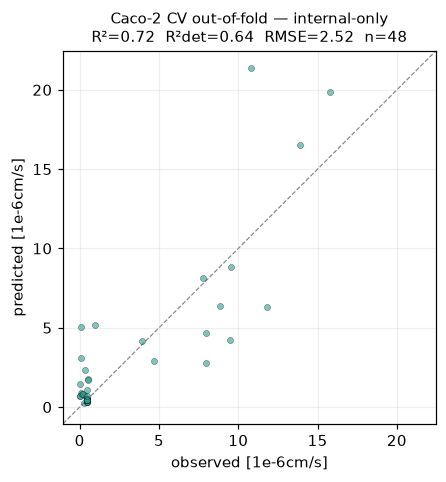

In [126]:
## show CV parity plot of the winner (internal-only)
ML_Reg.plot_parity_from_pred_df(sel_pred_df, title='Caco-2 CV out-of-fold — internal-only',
    unit=('1e-6cm/s' if RAW_VALUES else 'log10(1e-6cm/s)'), color='#2A9D8F', alpha=0.6)


In [129]:
## get classification metrics from pred_df - Caco-2  (cutoff = cv_winner median = placeholder 50/50 split; SET a domain cutoff in raw units)
_ctf = CUTOFFS['caco2']
_f1, _ppv, _cm, pred_caco2_labeled = ML_Class.classification_from_regression_pred(sel_pred_df, ctf_pred=_ctf, sign='>=', return_labels=True)
pred_caco2_labeled[['compound','real_y','pred_y','real_class','pred_class']].head()


> accuracy: 0.98, precision(PPV): 1.00, NPV: 0.98, F1(+): 0.86, F1(-): 0.99, MCC: 0.86
               pred_neg pred_pos    total
  real_neg           44        0       44
  real_pos            1        3        4
  total              45        3       48


,compound,real_y,pred_y,real_class,pred_class
0,SRB-0002171,0.3160,2.321674,False,False
1,SRB-0002184,8.8600,6.387570,False,False
2,SRB-0002188,0.0937,5.036938,False,False
3,SRB-0002248,0.9590,5.159539,False,False
4,SRB-0002790,0.0228,1.444171,False,False


#### 7. MDCK


In [23]:
## load prediction dfs: MDCK — internal CV + every augmentation source-combo (CV) + ALL rolling-origin temporal arms; RAW_VALUES-aware (log10)
## keys: cv_<sources> (sources: NVS+ADM) + temporal_{deployed=config policy / EXP=experimental-only / internal}; S2_exp_only collapses to 'internal' when no EXP
_SW='output/predictions_runs_admesweep/mdck'; _TE='output/predictions_runs_temporal/mdck'; _INV = lambda y: 10.0**y
_LBL = {'S0_all_raw': 'NVS_ADM', 'S1_all_phys': 'NVS_ADM_clip', 'S2_exp_only': 'internal', 'S3_drop_adm': 'NVS', 'S4_best_combo': 'NVS_clean'}   # sweep-strategy dir -> source-composition label
_TMAP = {'internal_only':'internal', 'previous_deployed':'deployed', 'experimental':'EXP'}
pred_mdck = {'internal_cv': pd.read_parquet('output/predictions_runs/mdck/pred_internal_cv.parquet')}
for _sd in sorted(glob(f'{_SW}/*/')):
    pred_mdck['cv_'+_LBL.get(os.path.basename(_sd.rstrip('/')), os.path.basename(_sd.rstrip('/')))] = pd.read_parquet(f'{_sd}pred_augmented_cv.parquet')
for _tf in sorted(glob(f'{_TE}/rolling_*.parquet')):
    _t = os.path.basename(_tf).replace('rolling_','').replace('.parquet','')
    pred_mdck['temporalRolling_'+_TMAP.get(_t, _t)] = pd.read_parquet(_tf)
for _ff in sorted(glob(f'output/predictions_runs_temporal_fractions/mdck/f*')):   # temporal fraction-split arms (RF + Chemprop)
    _lab = f'temporal{100 - int(os.path.basename(_ff)[1:])}_{os.path.basename(_ff)[1:]}'   # f30 -> temporal70_30
    for _pf in sorted(glob(f'{_ff}/*.parquet')):
        pred_mdck[f'{_lab}_{os.path.basename(_pf)[:-8]}'] = pd.read_parquet(_pf)
for _k, _d in pred_mdck.items():
    if RAW_VALUES: _d['real_y']=_INV(_d['real_y']); _d['pred_y']=_INV(_d['pred_y'])
    # print(f'{_k:22} n={len(_d):4}  cols={list(_d.columns)}')
pred_mdck['cv_winner'] = pred_mdck['cv_internal']                       # reconciled CV winner (alias; parity/classification use this)

## Summary metrics mdck: regression + classification for every pred_df (best per col = bold cyan, worst = orange; double rule = CV | temporal)
mdck_summary = endpoint_metrics_table(pred_mdck, 'mdck')

pred_df,source,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
internal_cv = cv_internal (winner),internal only,0.262,0.372,2.8,107,107,0.963,0,0.963,0,0.981,nan
cv_NVS_clean,Novartis,-0.191,0.503,3.56,107,40106,0.953,0.4,0.98,0.444,0.976,0.423
cv_NVS_ADM = cv_NVS_ADM_clip,Novartis + ADMETlab,-0.241,0.482,3.64,107,80107,0.953,0.429,0.99,0.545,0.975,0.546
cv_NVS,Novartis,-0.246,0.485,3.64,107,40107,0.944,0.333,0.98,0.4,0.971,0.38
temporalRolling_internal,internal only,0.229,0.701,1.38,54,96,0.981,0,0.981,0,0.991,nan
temporalRolling_deployed,Novartis,-2.28,0.451,2.85,54,40096,0.944,0,0.981,0,0.971,-0.0269
temporal80_20_rf_internal,?,0.442,0.94,0.883,22,nan,1,0,1,0,1,nan
temporal80_20_rf_NVS,?,-14.9,0.895,4.71,22,nan,0.909,0,1,0,0.952,nan
temporal80_20_cp_NVS,?,-17.7,0.956,5.11,22,nan,0.909,0,1,0,0.952,nan
temporal70_30_rf_internal,internal only,0.204,0.745,1.77,33,74,0.97,0,0.97,0,0.985,nan


In [24]:
sel_pred_df = pred_mdck['temporal70_30_cp_NVS']                        # selected pred_df carried to downstream analysis cells (repoint as needed)

<Axes: title={'center': 'MDCK CV out-of-fold — internal-only\nR²=0.83  R²det=-4.46  RMSE=4.64  n=33'}, xlabel='observed [1e-6cm/s]', ylabel='predicted [1e-6cm/s]'>

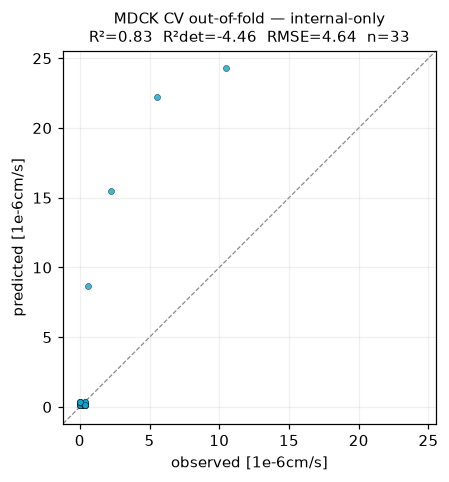

In [26]:
## show CV parity plot of the winner (internal-only)
ML_Reg.plot_parity_from_pred_df(sel_pred_df, title='MDCK CV out-of-fold — internal-only',
    unit=('1e-6cm/s' if RAW_VALUES else 'log10(1e-6cm/s)'), color=SERAC_C['azure'])

In [42]:
## get classification metrics from pred_df - MDCK  (cutoff = cv_winner median = placeholder 50/50 split; SET a domain cutoff in raw units)
_ctf = 1 # pred_mdck['cv_winner']['real_y'].median()
print('> median',pred_mdck['cv_winner']['real_y'].median())
_f1, _ppv, _cm, pred_mdck_labeled = ML_Class.classification_from_regression_pred(sel_pred_df, ctf_pred=_ctf, sign='>=', return_labels=True)
pred_mdck_labeled[['compound','real_y','pred_y','real_class','pred_class']].head()


> median 0.24000000000000002
> accuracy: 0.98, precision(PPV): 1.00, NPV: 0.98, F1(+): 0.80, F1(-): 0.99, MCC: 0.81
               pred_neg pred_pos    total
  real_neg           51        0       51
  real_pos            1        2        3
  total              52        2       54


,compound,real_y,pred_y,real_class,pred_class
0,SRB-0007804,0.10,0.257588,False,False
1,SRB-0007808,0.05,0.264611,False,False
2,SRB-0007811,0.38,0.300328,False,False
3,SRB-0007812,0.44,0.300328,False,False
4,SRB-0007813,0.32,0.330720,False,False


#### 8. PPB


In [20]:
## load prediction dfs: PPB — internal CV + every augmentation source-combo (CV) + ALL rolling-origin temporal arms; RAW_VALUES-aware (logit_pct)
## keys: cv_<sources> (sources: EXP+NVS+ADM) + temporal_{deployed=config policy / EXP=experimental-only / internal}; S2_exp_only collapses to 'internal' when no EXP
_SW='output/predictions_runs_admesweep/ppb'; _TE='output/predictions_runs_temporal/ppb'; _INV = lambda y: 100.0/(1.0+10.0**(-y))
_LBL = {'S0_all_raw': 'all', 'S1_all_phys': 'all_clip', 'S2_exp_only': 'EXP', 'S3_drop_adm': 'EXP_NVS', 'S4_best_combo': 'EXP_NVS_clean', 'S5_internal_only': 'internal'}   # sweep-strategy dir -> source-composition label
_TMAP = {'internal_only':'internal', 'previous_deployed':'deployed', 'experimental':'EXP'}
pred_ppb = {'internal_cv': pd.read_parquet('output/predictions_runs/ppb/pred_internal_cv.parquet')}
for _sd in sorted(glob(f'{_SW}/*/')):
    pred_ppb['cv_'+_LBL.get(os.path.basename(_sd.rstrip('/')), os.path.basename(_sd.rstrip('/')))] = pd.read_parquet(f'{_sd}pred_augmented_cv.parquet')
for _tf in sorted(glob(f'{_TE}/rolling_*.parquet')):
    _t = os.path.basename(_tf).replace('rolling_','').replace('.parquet','')
    pred_ppb['temporalRolling_'+_TMAP.get(_t, _t)] = pd.read_parquet(_tf)
for _ff in sorted(glob(f'output/predictions_runs_temporal_fractions/ppb/f*')):   # temporal fraction-split arms (RF + Chemprop)
    _lab = f'temporal{100 - int(os.path.basename(_ff)[1:])}_{os.path.basename(_ff)[1:]}'   # f30 -> temporal70_30
    for _pf in sorted(glob(f'{_ff}/*.parquet')):
        pred_ppb[f'{_lab}_{os.path.basename(_pf)[:-8]}'] = pd.read_parquet(_pf)
for _k, _d in pred_ppb.items():
    if RAW_VALUES: _d['real_y']=_INV(_d['real_y']); _d['pred_y']=_INV(_d['pred_y'])
    # print(f'{_k:22} n={len(_d):4}  cols={list(_d.columns)}')
pred_ppb['cv_winner'] = pred_ppb['cv_EXP']                       # reconciled CV winner (alias; parity/classification use this)
sel_pred_df = pred_ppb['temporalRolling_internal']                        # selected pred_df carried to downstream analysis cells (repoint as needed)

## Summary metrics ppb: regression + classification for every pred_df (best per col = bold cyan, worst = orange; double rule = CV | temporal)
ppb_summary = endpoint_metrics_table(pred_ppb, 'ppb')

pred_df,source,R2_det,R2_pears,RMSE,N,n_train,Accuracy,PPV,NPV,F1(+),F1(-),MCC
cv_all = cv_all_clip,AstraZeneca/Biogen + Novartis + ADMETlab,0.383,0.404,2.3,69,81877,0.652,0.786,0.618,0.478,0.739,0.326
cv_EXP_NVS,AstraZeneca/Biogen + Novartis,0.336,0.488,2.39,69,41877,0.71,0.773,0.681,0.63,0.762,0.424
cv_EXP_NVS_clean,AstraZeneca/Biogen + Novartis,0.319,0.479,2.42,69,41846,0.696,0.739,0.674,0.618,0.747,0.39
cv_EXP (winner),AstraZeneca/Biogen,0.279,0.435,2.49,69,1877,0.725,0.76,0.705,0.667,0.765,0.448
internal_cv = cv_internal,internal only,0.15,0.325,2.7,69,69,0.754,0.727,0.778,0.738,0.767,0.506
temporalRolling_deployed,AstraZeneca/Biogen + Novartis,0.114,0.15,1.23,35,40062,0.571,0.857,0.5,0.444,0.651,0.289
temporalRolling_EXP,AstraZeneca/Biogen,0.0717,0.107,1.26,35,1870,0.543,0.667,0.478,0.5,0.579,0.139
temporalRolling_internal,internal only,-0.281,7.16e-05,1.48,35,62,0.571,0.692,0.5,0.545,0.595,0.188
temporal70_30_rf_EXP_NVS,AstraZeneca/Biogen + Novartis,0.121,0.291,1.32,21,275494,0.429,1,0.4,0.143,0.571,0.175
temporal70_30_rf_internal,internal only,-0.426,0.00616,1.68,21,48,0.714,0.818,0.6,0.75,0.667,0.43


In [ ]:
## show CV parity plot of the winner (EXP-only)
ML_Reg.plot_parity_from_pred_df(pred_ppb['cv_winner'], title='PPB CV out-of-fold — EXP-only',
    unit=('pct_unbound' if RAW_VALUES else 'logit(fu)'), color='#2A9D8F', alpha=0.6)


In [ ]:
## get classification metrics from pred_df - PPB  (cutoff = cv_winner median = placeholder 50/50 split; SET a domain cutoff in raw units)
_ctf = pred_ppb['cv_winner']['real_y'].median()
_f1, _ppv, _cm, pred_ppb_labeled = ML_Class.classification_from_regression_pred(pred_ppb['cv_winner'], ctf_pred=_ctf, sign='>=', return_labels=True)
pred_ppb_labeled[['compound','real_y','pred_y','real_class','pred_class']].head()

#### 9. Summary figure

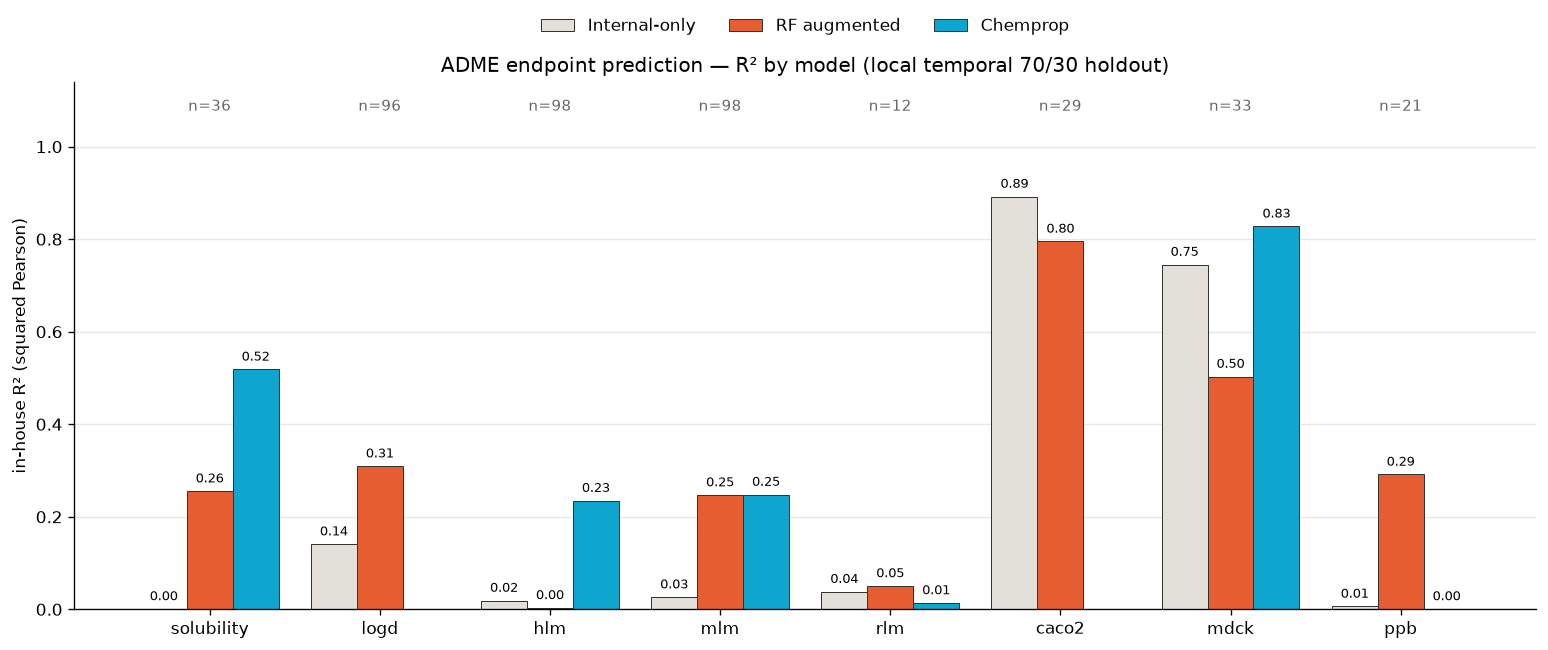

In [21]:
## make summary figure for temporal set — grouped R² bars (toggle 70/30 vs 80/20)
TEMPORAL_SPLIT = '70_30'                                    # <-- toggle: '70_30' or '80_20'
ADME8 = ['solubility', 'logd', 'hlm', 'mlm', 'rlm', 'caco2', 'mdck', 'ppb']
PREDS = {'solubility': pred_sol, 'logd': pred_logd, 'hlm': pred_hlm, 'mlm': pred_mlm,
         'rlm': pred_rlm, 'caco2': pred_caco2, 'mdck': pred_mdck, 'ppb': pred_ppb}
_pal = yaml.safe_load(open('config/config.yaml'))['SERAC_C']
BARS = [('Internal-only', _pal['paper']), ('RF augmented', _pal['ember']), ('Chemprop', _pal['azure'])]

def _r2p(df):                                               # squared Pearson (== table R2_pears; respects RAW_VALUES)
    d = df.dropna(subset=['real_y', 'pred_y']); yo, yp = d['real_y'].to_numpy(float), d['pred_y'].to_numpy(float)
    return (np.corrcoef(yo, yp)[0, 1] ** 2 if len(d) > 1 and yo.std() > 0 else np.nan, len(d))

def _split_keys(pred):
    pre = f'temporal{TEMPORAL_SPLIT}_'; keys = [k for k in pred if k.startswith(pre)]
    internal = next((k for k in keys if k.endswith('rf_internal')), None)
    aug = sorted([k for k in keys if '_rf_' in k and not k.endswith('rf_internal')], key=lambda k: k.count('_'))
    rf_aug = aug[-1] if aug else None                       # richest RF augmentation arm
    cp = [k for k in keys if '_cp_' in k]
    if rf_aug and cp:                                       # prefer chemprop on the SAME sources as RF augmented
        arm = rf_aug.split('_rf_', 1)[1]; cp = [k for k in cp if k.endswith(f'_cp_{arm}')] or cp
    return internal, rf_aug, (cp[-1] if cp else None)

vals = [[], [], []]; ns = []
for ep in ADME8:
    ks = _split_keys(PREDS[ep]); n_ep = np.nan
    for j, k in enumerate(ks):
        r2, n = _r2p(PREDS[ep][k]) if k else (np.nan, np.nan)
        vals[j].append(r2)
        if j == 0: n_ep = n
    ns.append(n_ep)

fig, ax = plt.subplots(figsize=(13, 5.5), dpi=120)
x = np.arange(len(ADME8)); w = 0.27
for j, (lbl, col) in enumerate(BARS):
    xs = x + (j - 1) * w
    ax.bar(xs, [0 if pd.isna(v) else v for v in vals[j]], w, label=lbl, color=col, edgecolor='#333', linewidth=0.6)
    for xi, v in zip(xs, vals[j]):
        if not pd.isna(v): ax.text(xi, v + 0.012, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
for xi, n in zip(x, ns):
    if not pd.isna(n): ax.text(xi, 1.07, f'n={int(n)}', ha='center', va='bottom', fontsize=9, color='#666')
ax.set_xticks(x); ax.set_xticklabels(ADME8); ax.set_ylim(0, 1.14); ax.set_axisbelow(True)
ax.set_ylabel('in-house R² (squared Pearson)')
ax.set_title(f'ADME endpoint prediction — R² by model (local temporal {TEMPORAL_SPLIT.replace("_", "/")} holdout)')
ax.legend(ncol=3, loc='upper center', bbox_to_anchor=(0.5, 1.15), frameon=False)
ax.grid(axis='y', alpha=0.3)
for s in ('top', 'right'): ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()
